In [1]:
import copy
from pprint import pprint

import numpy as np
import pandas as pd
from parse import parse
from pathlib import Path

In [2]:
from ase.data import chemical_symbols

# Create the dictionary using a dict comprehension
num_to_symbol = {i: symbol for i, symbol in enumerate(chemical_symbols) if i > 0}

# Example lookup
#print(num_to_symbol[6])   # Output: 'C'
#print(num_to_symbol[12])  # Output: 'Mg'

In [3]:
def parse_grrm_saddlepoint_irc_log(log_file_path: Path, num_atoms = 12) -> dict:
    """This function parses a single log file from a specific assumed set of input parameters in a .com file submitted to GRRM.

    See the `assemble_com()` function for the pattern of the .com file which is assumed to be the basis for the log file to be
    parsed by this function. 

    
    """
    log_parsing_results = {"initial_TS_energy": None,
                           "initial_TS_geometry": None,
                           "initial_TS_frequencies": None,
                           "initial_TS_single_neg_freq_confirmed": False,
                           "saddle_point_found": False,
                           "reopt_TS_energy": None,
                           "reopt_TS_geometry": None,
                           "reopt_TS_num_steps": None,
                           "reopt_TS_frequencies": None,
                           "reopt_TS_single_neg_freq_confirmed": False,
                           "1st_irc_EQ_energy": None,
                           "1st_irc_EQ_geometry": None,
                           "2nd_irc_EQ_energy": None,
                           "2nd_irc_EQ_geometry": None,
                          }
    
    itr_header_pattern = "# ITR. {iter_num}"
    consuming_coordinates = False
    start_consuming_coordinates_at = -1 
    stop_consuming_coordinates_at = -1 
    consuming_energy = False
    consume_energy_at = -1
    saddle_point_found = False
    optimized_structure = False
    consuming_freq = False
    reopt_TS_frequencies = []
    
    # With saddle point optimization AND IRC, we have three stages of the log:
    # Stage 1: re-optimization of candidate TS to true saddle point.
    # Stage 2: first EQ-finding by IRC.
    # Stage 3: second EQ-finding by IRC.
    
    stage = 1 
    
    with open(log_file_path, "r") as f: 
        for i, line in enumerate(f):
            if line.startswith("# ITR."):
                iter_parsed = parse(itr_header_pattern, line)
                iter_num = int(iter_parsed["iter_num"])
                if stage == 1 and iter_num == 0:
                    consuming_energy = True
                    consume_energy_at = i + num_atoms + 2
                    consuming_coordinates = True
                    start_consuming_coordinates_at = i+1
                    stop_consuming_coordinates_at = i+num_atoms
                    temp_coords = []
            elif line.startswith("Optimized structure"):
                optimized_structure = True
                consuming_energy = True
                consume_energy_at = i + num_atoms + 1
                consuming_coordinates = True
                start_consuming_coordinates_at = i+1
                stop_consuming_coordinates_at = i+num_atoms
                temp_coords = []
            elif line.startswith("1st-Order Saddle point was found"):
                saddle_point_found = True
                log_parsing_results["saddle_point_found"] = saddle_point_found
                #print(f"Saddle point was found after {iter_num} iterations.")
            elif saddle_point_found and line.startswith("FREQFREQFREQ") and len(reopt_TS_frequencies) == 0:
                #print("Toggling frequency parsing on.")
                consuming_freq = True
            elif (consuming_freq) and (line.startswith("Freq.  :")):
                temp_freqs = [float(x) for x in line.rstrip().split()[-3:]]
                for x in temp_freqs:
                    reopt_TS_frequencies.append(x)
                if len(reopt_TS_frequencies) == 30:
                    #print("Toggling frequency parsing off.\n")
                    consuming_freq = False
                    log_parsing_results["reopt_TS_frequencies"] = copy.deepcopy(reopt_TS_frequencies)
                    if reopt_TS_frequencies[0] < 0.0 and all([x >= 0.0 for x in reopt_TS_frequencies[1:]]):
                        log_parsing_results["reopt_TS_single_neg_freq_confirmed"] = True
            # Adding sanity check on initial state -- does it have a single negative frequency?
            elif line.startswith("NORMAL MODE EIGENVALUE : N_MODE = 30") and stage == 1 and iter_num == 0:
                consuming_freq = True
                initial_TS_frequencies = []
            elif consuming_freq and stage == 1 and iter_num == 0:
                temp_freqs = [float(x) for x in line.strip().split()]
                for x in temp_freqs:
                    initial_TS_frequencies.append(x)
                if len(initial_TS_frequencies) == 30:
                    consuming_freq = False
                    log_parsing_results["initial_TS_frequencies"] = copy.deepcopy(initial_TS_frequencies)
                    if initial_TS_frequencies[0] < 0.0 and all([x >= 0.0 for x in initial_TS_frequencies[1:]]):
                        log_parsing_results["initial_TS_single_neg_freq_confirmed"] = True
            if consuming_coordinates and start_consuming_coordinates_at <= i:
                temp_coord_row = [line.strip().split()[0]] + [float(x) for x in line.rstrip().split()[1:]]
                temp_coords.append(temp_coord_row)
                if stop_consuming_coordinates_at == i:
                    consuming_coordinates = False
                    if stage == 1 and iter_num == 0:
                        log_parsing_results["initial_TS_geometry"] = copy.deepcopy(temp_coords)
                    elif optimized_structure:
                        if stage == 1:
                            log_parsing_results["reopt_TS_geometry"] = copy.deepcopy(temp_coords)
                        elif stage == 2:
                            log_parsing_results["1st_irc_EQ_geometry"] = copy.deepcopy(temp_coords)
                        elif stage == 3:
                            log_parsing_results["2nd_irc_EQ_geometry"] = copy.deepcopy(temp_coords)
            if consuming_energy and consume_energy_at == i:
                if stage == 1 and iter_num == 0:
                    log_parsing_results["initial_TS_energy"] = float(line.split()[1])
                elif optimized_structure:
                    #print("Found optimized structure and energy.")
                    temp_energy = float(line.rstrip().split()[2])
                    if stage == 1:
                        log_parsing_results["reopt_TS_energy"] = temp_energy
                        log_parsing_results["reopt_TS_num_steps"] = iter_num
                    elif stage == 2:
                        log_parsing_results["1st_irc_EQ_energy"] = temp_energy
                    elif stage == 3:
                        log_parsing_results["2nd_irc_EQ_energy"] = temp_energy
                    optimized_structure = False
                    if stage <= 2:
                        stage += 1
                consuming_energy = False
                consume_energy_at = -1
    return log_parsing_results

In [4]:
# DONE add check if initial state has single negative frequency --> sanity check. 
# If so, it should not be very different eventual saddle-point. An IRC EQs should match. 

In [5]:
#pprint(log_parsing_results, sort_dicts=False)

In [6]:
def assemble_xyz(z: list, pos: np.array) -> str:
    """Assembling atomic numbers and positions into xyz format

    Args:
        z (list): chemical elements
        pos (tensor): 3D coordinates

    Returns:
        str: xyz string
    """
    natoms =len(z)
    xyz = f"{natoms}\n\n"
    for _z, _pos in zip(z, pos): #.numpy()):
        xyz += f"{_z}\t" + "\t".join([str(x) for x in _pos]) + "\n"
    return xyz

In [7]:
def assemble_com(geom: list) -> str:
    """Assembling atomic numbers and positions into .com format

    Args:
        z (list): chemical elements
        pos (tensor): 3D coordinates

    Returns:
        str: xyz string
    """
    coords_block = "\n".join(["\t".join([str(y) for y in x]) for x in geom])+"\n"
    return f'''# SADDLE/B3LYP/Def2SVPP Int(Grid=FineGrid) EmpiricalDispersion=GD3

0 1
{coords_block.rstrip()}
Options
Saddle+IRC
DownDC = 99999
EigenCheck
GauProc=40
GauMem=200
'''

In [8]:
log_parsing_results = parse_grrm_saddlepoint_irc_log("scratch/C6H6_saddle_validation/C6H6_irc-val_ref_example.log")
# NB 'C6H6_5710-TS12 CON(2,6)' --> "scratch/C6H6_saddle_validation/C6H6_irc-val_ref_example.log"

com_block = assemble_com(log_parsing_results["initial_TS_geometry"])
print(com_block)

# SADDLE/B3LYP/Def2SVPP Int(Grid=FineGrid) EmpiricalDispersion=GD3

0 1
C	-0.03560272	-0.27134174	-1.5551164
C	-1.0147139	-0.04375157	-0.58207583
C	1.2424026	0.083484	-1.1180137
C	-0.54334307	0.46321496	0.7129997
C	1.2926998	0.3485111	0.27941152
C	-0.586081	-0.48620486	1.7599235
H	-2.0806084	-0.25336453	-0.7431103
H	1.7082402	1.3001873	0.6440455
H	-0.81180584	-1.5127023	1.3673085
H	1.745792	-0.49068445	0.8312485
H	-0.64512765	1.5350078	0.94996226
H	-0.2718522	-0.6723557	-2.5465832
Options
Saddle+IRC
DownDC = 99999
EigenCheck
GauProc=40
GauMem=200



In [9]:
#pprint(log_parsing_results, sort_dicts=False)

In [10]:
#with open("scratch/C6H6_saddle_validation/recreation-val-C6H6_irc-val_new_model_example.com", "w") as f:
#    f.write(com_block)

In [11]:
!cat scratch/C6H6_saddle_validation/C6H6_irc-val_new_model_example.com

# SADDLE/B3LYP/Def2SVPP Int(Grid=FineGrid) EmpiricalDispersion=GD3

0 1
C       -0.1385524172364524     -1.2895242342355837     -0.7607652901753402
C       -0.5746187159788264     1.1485610804884538      0.848903484647897
C       -0.43944556590990613    -1.3527369867314836     0.5051870850523872
C       0.23428055555705848     -0.05296881440221325    -1.4043258483621284
C       0.47971960191411184     0.8922688413213409      -0.054627277359575295
C       0.1317284754451082      -0.05383297277965539    1.1715038246435192
H       -1.6438144149385339     1.3403581628136956      0.7009595484863388
H       1.1587655352566293      -0.050997884501638606   -2.0300235898723886
H       -0.9498021996291618     -2.1129675287441425     1.1082410361243584
H       0.8810486914032343      -0.2468647014568118     1.942075259586514
H       1.441659302798145       1.397399397067585       -0.05456898430019256
H       -0.5809688486814069     0.3813056411604537      -1.9725592484713896
Options
Saddle+IRC
Do

In [12]:
!cat scratch/C6H6_saddle_validation/recreation-test-C6H6_irc-val_new_model_example.com

# SADDLE/B3LYP/Def2SVPP Int(Grid=FineGrid) EmpiricalDispersion=GD3

0 1
C	-0.138552417236	-1.289524234236	-0.760765290175
C	-0.574618715979	1.148561080488	0.848903484648
C	-0.43944556591	-1.352736986731	0.505187085052
C	0.234280555557	-0.052968814402	-1.404325848362
C	0.479719601914	0.892268841321	-0.05462727736
C	0.131728475445	-0.05383297278	1.171503824644
H	-1.643814414939	1.340358162814	0.700959548486
H	1.158765535257	-0.050997884502	-2.030023589872
H	-0.949802199629	-2.112967528744	1.108241036124
H	0.881048691403	-0.246864701457	1.942075259587
H	1.441659302798	1.397399397068	-0.0545689843
H	-0.580968848681	0.38130564116	-1.972559248471

Options
Saddle+IRC
DownDC = 99999
EigenCheck
GauProc=40
GauMem=200


In [13]:
import pymatgen

In [14]:
import os

from ase.io import read, write

generated_val_instances_dir = os.path.abspath("/misc/home/guest50/OAReactDiff/results/sample_random_TS-20260626-C6H6-filtered_new-w_wo-w_wo-w_wo-vs_www_valid/")

In [15]:
from ase.io import read
import io

def read_xyz_with_raw_comments(filename):
    """
    Reads an XYZ trajectory and treats the second line of each frame 
    strictly as a single string comment.
    """
    with open(filename, 'r') as f:
        while True:
            # 1. Read the number of atoms
            line = f.readline()
            if not line: break
            natoms = int(line.strip())
            
            # 2. Grab the entire comment line as a single string
            raw_comment = f.readline().strip()
            
            # 3. Read the coordinate block
            coords_lines = [f.readline() for _ in range(natoms)]
            
            # 4. Use io.StringIO to let ASE parse only the coordinates
            xyz_data = f"{natoms}\n{raw_comment}\n" + "".join(coords_lines)
            atoms = read(io.StringIO(xyz_data), format='xyz')
            
            # 5. Force the comment into the info dict as a single value
            atoms.info["comment"] = raw_comment
            
            yield atoms

In [16]:
# This cell is just to check what models are covered:
# UPDATE:
generated_instances_dir = os.path.abspath("/misc/home/guest50/OAReactDiff/results/sample_random_TS-20260707-C6H6_5710-0-woSL-woBL-wow3pBC-StepLR-cutoff_12-bz64-C6H6_filtered-combined_Ts1X-valid_split/")

files = [f for f in os.listdir(generated_instances_dir) if os.path.isfile(os.path.join(generated_instances_dir, f)) and f.endswith(".xyz")]


for file in files:
    file_path = os.path.join(generated_instances_dir, file)
    temp_atoms = [atoms for atoms in read_xyz_with_raw_comments(file_path)]
    #ts_name = file.replace(" ", "_").replace("(","_").replace(")","_").replace(",","-")[:-4]
    parsed = parse("{network_name}-TS{ts_id_num} CON({eq_id_1},{eq_id_2}).xyz", file) # 'C6H6_5710-TS142 CON(17,23)'
    network_name = parsed['network_name'] 
    ts_id_num  = parsed['ts_id_num']
    eq_id_1 = parsed['eq_id_1']
    eq_id_2 = parsed['eq_id_2']
    ts_com_file = f"{network_name}-TS{ts_id_num}_CON_{eq_id_1}-{eq_id_2}_.com"
    for i in range(len(temp_atoms)):
        instance_to_check = temp_atoms[i]
        print(f'{i}: {instance_to_check.info["comment"]}')
    break

0: True/calculated reference reactant state.
1: True/calculated reference transition state.
2: True/calculated reference product state.
3: Generated/inpainted transition state. RMSD: 1.0 Å. By model /misc/home/guest50/OAReactDiff/oa_reactdiff/trainer/checkpoint/OAReactDiff-SCAN/C6H6_5710-0-woSL-wBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet22b35e509597/ddpm-epoch=2891-val-totloss=478.62.ckpt.
4: Generated/inpainted transition state. RMSD: 0.327926 Å. By model /misc/home/guest50/OAReactDiff/oa_reactdiff/trainer/checkpoint/OAReactDiff-SCAN/C6H6_5710-0-wSL-woBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet0c6a5355a394/ddpm-epoch=2653-val-totloss=476.31.ckpt.
5: Generated/inpainted transition state. RMSD: 1.0 Å. By model /misc/home/guest50/OAReactDiff/oa_reactdiff/trainer/checkpoint/OAReactDiff-SCAN/C6H6_5710-0-wSL-woBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet0c6a5355a394/ddpm-epoch=2168-val-totloss=472.29.ckpt.
6: Generated/inpainted transition state. RMSD: 0.027627 Å. By model

In [17]:
# This cell is just to recover OA-ReactDiff RMSD stats:
from collections import defaultdict

# UPDATE:
generated_instances_dir = os.path.abspath("/misc/home/guest50/OAReactDiff/results/sample_random_TS-20260707-C6H6_5710-0-woSL-woBL-wow3pBC-StepLR-cutoff_12-bz64-C6H6_filtered-combined_Ts1X-valid_split/")

files = [f for f in os.listdir(generated_instances_dir) if os.path.isfile(os.path.join(generated_instances_dir, f)) and f.endswith(".xyz")]

model_RMSD_data = defaultdict(list)
model_names = []

comment_pattern = "Generated/inpainted transition state. RMSD: {rmsd} Å. By model /misc/home/guest50/OAReactDiff/oa_reactdiff/trainer/checkpoint/OAReactDiff-SCAN/{model_name}.ckpt."

for file in files:
    file_path = os.path.join(generated_instances_dir, file)
    temp_atoms = [atoms for atoms in read_xyz_with_raw_comments(file_path)][3:]
    parsed = parse("{network_name}-TS{ts_id_num} CON({eq_id_1},{eq_id_2}).xyz", file) 
    network_name = parsed['network_name'] 
    ts_id_num  = parsed['ts_id_num']
    eq_id_1 = parsed['eq_id_1']
    eq_id_2 = parsed['eq_id_2']
    rxn_id = f"{network_name}-TS{ts_id_num} CON({eq_id_1},{eq_id_2})"
    model_RMSD_data["rxn_id"].append(rxn_id)
    for i in range(len(temp_atoms)):
        instance_to_check = temp_atoms[i]
        comment = instance_to_check.info["comment"]
        parsed_comment = parse(comment_pattern, comment)
        rmsd = float(parsed_comment["rmsd"])
        model_name = parsed_comment["model_name"]
        model_RMSD_data[model_name].append(rmsd)
        if model_name not in model_names:
            model_names.append(model_name)

df_model_rmsd = pd.DataFrame(data=model_RMSD_data)
assert model_names == [x for x in list(df_model_rmsd.columns) if x != "rxn_id"]

print("Model name                                                                                                          | RMSD mean (st.dev) (Å)")
for model_name in model_names:
    rmsd_values = [x for x in df_model_rmsd[model_name].values.tolist() if x != 1.0]
    # rmsd_values = df_model_rmsd[model_name].values.tolist()
    mean_rmsd = np.mean(rmsd_values)
    stdev_rmsd = np.std(rmsd_values)
    
    print(f"{model_name[10:]:116}:  {mean_rmsd:.5f}  ({stdev_rmsd:.5f})")

Model name                                                                                                          | RMSD mean (st.dev) (Å)
0-woSL-wBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet22b35e509597/ddpm-epoch=2891-val-totloss=478.62            :  0.20533  (0.16416)
0-wSL-woBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet0c6a5355a394/ddpm-epoch=2653-val-totloss=476.31            :  0.21848  (0.17338)
0-wSL-woBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet0c6a5355a394/ddpm-epoch=2168-val-totloss=472.29            :  0.23240  (0.18610)
0-wSL-woBL-w3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnetd095e07080e3/ddpm-epoch=2912-val-totloss=470.72             :  0.21447  (0.18124)
0-wSL-wBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnetad3824c569fd/ddpm-epoch=2952-val-totloss=485.94             :  0.22376  (0.19178)
0-wSL-wBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnetad3824c569fd/ddpm-epoch=2742-val-totloss=482.00             :  0.20800  (0.18844)
0-wSL-wBL-wo3pBC-StepLR-cutoff_

In [18]:
pprint(model_names)

['C6H6_5710-0-woSL-wBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet22b35e509597/ddpm-epoch=2891-val-totloss=478.62',
 'C6H6_5710-0-wSL-woBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet0c6a5355a394/ddpm-epoch=2653-val-totloss=476.31',
 'C6H6_5710-0-wSL-woBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet0c6a5355a394/ddpm-epoch=2168-val-totloss=472.29',
 'C6H6_5710-0-wSL-woBL-w3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnetd095e07080e3/ddpm-epoch=2912-val-totloss=470.72',
 'C6H6_5710-0-wSL-wBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnetad3824c569fd/ddpm-epoch=2952-val-totloss=485.94',
 'C6H6_5710-0-wSL-wBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnetad3824c569fd/ddpm-epoch=2742-val-totloss=482.00',
 'C6H6_5710-0-wSL-wBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnetad3824c569fd/ddpm-epoch=2741-val-totloss=476.26',
 'C6H6_5710-0-wSL-wBL-wo3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnetad3824c569fd/ddpm-epoch=2307-val-totloss=476.12',
 'C6H6_5710-0-wSL-wBL-w3pBC-StepLR-cutoff_12-bz64-rep

In [19]:
len("combined_C6H6_570-filtered_and_Ts1x-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet058abd800eca/ddpm-epoch=2947-val-totloss=470.7")

125

## 01/07/2026

Cleaned up a bit, made the log parsing loop into a per-log-file function. 

In [20]:
log_files_dir = Path("/misc/home/guest50/OAReactDiff/results/sample_random_TS-20260626-C6H6-filtered_new-w_wo-w_wo-w_wo-vs_www_valid/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68/") # UPDATE

log_files = [f for f in os.listdir(log_files_dir) if os.path.isfile(os.path.join(log_files_dir, f)) and f[-4:] == ".log"]
len(log_files)

100

### 1. Compare one log file's results to its respective reference data. 



In [21]:
log_file = log_files[6]
log_parsing_results = parse_grrm_saddlepoint_irc_log(log_files_dir / log_file)

parsed = parse("{network_name}-TS{ts_id_num}_CON_{eq_id_1}-{eq_id_2}_.log", log_file)
network_name = parsed['network_name'] 
ts_id_num  = parsed['ts_id_num']
eq_id_1 = parsed['eq_id_1']
eq_id_2 = parsed['eq_id_2']
ts_xyz_file = f"{network_name}-TS{ts_id_num} CON({eq_id_1},{eq_id_2}).xyz"
ref_atoms = read(Path(generated_val_instances_dir) / ts_xyz_file, index=":")[0:3]
len(ref_atoms)



3

In [22]:
#pprint(log_parsing_results, sort_dicts=False) # TS initial state confirmed.

In [23]:
import ase
import py3Dmol
from io import StringIO

def draw_in_3dmol(mol: str, fmt: str = "xyz") -> py3Dmol.view:
    """Draw the molecule

    Args:
        mol (str): str content of molecule.
        fmt (str, optional): format. Defaults to "xyz".

    Returns:
        py3Dmol.view: output viewer
    """
    viewer = py3Dmol.view(1024, 576)
    viewer.addModel(mol, fmt)
    viewer.setStyle({'stick': {}, "sphere": {"radius": 0.36}})
    viewer.zoomTo()
    return viewer

def atoms_to_xyz_str(atoms: ase.Atoms):
    f = StringIO()
    atoms.write(f, format="xyz")
    return f.getvalue()

def xyz_str_to_atoms(xyz_str: str):
    atoms = read(StringIO(xyz_str), format="xyz")
    return atoms
# draw_in_3dmol(atoms_to_xyz_str(atoms[-1]))

In [24]:
atoms = read('/misc/home/guest50/OAReactDiff/results/sample_random_TS-20260626-C6H6-filtered_new-w_wo-w_wo-w_wo-vs_www_valid/C6H6_5710-TS18622 CON(195,71).xyz', format='xyz',index=":")

In [25]:
!head -n 42 "/misc/home/guest50/OAReactDiff/results/sample_random_TS-20260626-C6H6-filtered_new-w_wo-w_wo-w_wo-vs_www_valid/C6H6_5710-TS18622 CON(195,71).xyz"

12
True/calculated reference reactant state.
C	-0.64518625	0.2447242	-1.683171
C	0.13141951	-0.79333	-1.7420098
C	0.7221887	0.42801055	-1.0730848
C	-0.8208481	-0.30277622	2.2158253
C	0.9219525	0.49097505	0.4189521
C	0.055722147	0.097144775	1.3265454
H	-1.617357	0.71064174	-1.8389342
H	0.2999874	-1.8419049	-1.9835051
H	-0.832695	-1.3374037	2.5891464
H	1.8824017	0.905396	0.75994915
H	-1.576706	0.3812367	2.6290455
H	1.4791207	1.0172857	-1.6187587
12
True/calculated reference transition state.
C	-0.03560272	-0.27134174	-1.5551164
C	-1.0147139	-0.04375157	-0.58207583
C	1.2424026	0.083484	-1.1180137
C	-0.54334307	0.46321496	0.7129997
C	1.2926998	0.3485111	0.27941152
C	-0.586081	-0.48620486	1.7599235
H	-2.0806084	-0.25336453	-0.7431103
H	1.7082402	1.3001873	0.6440455
H	-0.81180584	-1.5127023	1.3673085
H	1.745792	-0.49068445	0.8312485
H	-0.64512765	1.5350078	0.94996226
H	-0.2718522	-0.6723557	-2.5465832
12
True/calculated reference product state.
C	-0.054861784	-0.26756024	-1.5816629
C	-1.0227

In [26]:
node_features_ref_ts_xyz = '''12
True/calculated reference transition state.
C	-0.03560272	-0.27134174	-1.5551164
C	-1.0147139	-0.04375157	-0.58207583
C	1.2424026	0.083484	-1.1180137
C	-0.54334307	0.46321496	0.7129997
C	1.2926998	0.3485111	0.27941152
C	-0.586081	-0.48620486	1.7599235
H	-2.0806084	-0.25336453	-0.7431103
H	1.7082402	1.3001873	0.6440455
H	-0.81180584	-1.5127023	1.3673085
H	1.745792	-0.49068445	0.8312485
H	-0.64512765	1.5350078	0.94996226
H	-0.2718522	-0.6723557	-2.5465832'''
draw_in_3dmol(node_features_ref_ts_xyz)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [27]:
# Note that this "reference state" is via xyz_block_from_node_features ... but why?

In [28]:
import pickle

npz_path_val = "/scr/trond/SCAN/C6H6_5710-filtered-valid.pkl"
val_pkl = pickle.load(open(npz_path_val, "rb"))
for i in range(len(val_pkl["transition_state"]["rxn"])):
    #if np.allclose(val_pkl["transition_state"]["positions"][i][0], np.array([-0.03560272, -0.27134174, -1.5551164]), rtol=1e-05):
    #val_pkl["transition_state"]["rxn"][i] == 'C6H6_5710-TS12 CON(2,6)':
    if val_pkl["transition_state"]["rxn"][i] == "C6H6_5710-TS18622 CON(195,71)":
        print(i)
        print(val_pkl["transition_state"]["rxn"][i])
        pos = np.array(val_pkl['transition_state']['positions'][i])
        z_num = val_pkl['transition_state']['charges'][i]
        num2sym = {1: "H", 6: "C"}
        val_xyz = assemble_xyz([num2sym[num] for num in z_num], pos)
        print(val_xyz)
        

6580
C6H6_5710-TS18622 CON(195,71)
12

C	-0.37653042916999996	-0.27134173101	-1.3394274234330001
C	-1.355641565687	-0.043751569897	-0.3663868979839999
C	0.901474901004	0.08348399821200002	-0.902324771343
C	-0.8842707927	0.463214961394	0.9286886711349999
C	0.951772074556	0.348511105048	0.495100504034
C	-0.927008762207	-0.48620486696599996	1.975612450387
H	-2.421535957442	-0.253364541942	-0.527421280324
H	1.3673124024879997	1.3001872912159997	0.859734388587
H	-1.152733510099	-1.512702294698	1.582997489117
H	1.404864356449	-0.490684448184	1.046937436034
H	-0.986055344707	1.535007827151	1.165651209646
H	-0.6127799024759999	-0.6723557303459999	-2.330894255843



In [29]:
draw_in_3dmol(val_xyz)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [30]:
# Is it possible that the output reference TS is just rigidly transformed? 
from pymatgen.analysis.molecule_matcher import GeneticOrderMatcher
from pymatgen.core import Molecule

threshold = 0.05

node_features_ref_ts_atoms = read(StringIO(node_features_ref_ts_xyz), format="xyz")
nf_ref_ts_mol = Molecule(list(node_features_ref_ts_atoms.symbols), node_features_ref_ts_atoms.positions)
val_ref_ts_atoms = read(StringIO(val_xyz), format="xyz")
val_ref_ts_mol = Molecule(list(val_ref_ts_atoms.symbols), val_ref_ts_atoms.positions)

matcher = GeneticOrderMatcher(val_ref_ts_mol, threshold=threshold)

try:
    best_rmsd = None
    best_mirror_rmsd = None
    results = matcher.fit(nf_ref_ts_mol)
    if results:
        results.sort(key=lambda x: x[1])
        best_match, best_rmsd = results[0]
        
    mirror_nf_ref_ts_mol = Molecule(nf_ref_ts_mol.species, -1 * nf_ref_ts_mol.cart_coords)
    mirror_results = matcher.fit(mirror_nf_ref_ts_mol)
    if mirror_results:
        results.sort(key=lambda x: x[1])
        best_mirror_match, best_mirror_rmsd = results[0]
    if best_rmsd is not None and best_mirror_rmsd is not None:
        if best_rmsd > best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å. 1")
        elif best_rmsd < best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
        elif best_rmsd == best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (identical irrespective of mirroring)")
    elif best_rmsd is not None:
        print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å. 2")
    elif best_mirror_rmsd is not None:
        print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
    else:
        print("Acceptable RMSD was not found.")
except Exception as e:
    print(f"Could not calculate RMSD on first ref EQ: {e}")


Lowest Coordinate-based RMSD: 0.0000 Å. 2


In [31]:
# 07/07/2026 a generated instance vs the corresponding reference TS:
from pymatgen.analysis.molecule_matcher import GeneticOrderMatcher
from pymatgen.core import Molecule


#npz_path_test = "/scr/trond/SCAN/C6H6_5710-filtered-test.pkl"
#test_pkl = pickle.load(open(npz_path_test, "rb"))
#for i in range(len(test_pkl["transition_state"]["rxn"])):
#    if test_pkl["transition_state"]["rxn"][i] == "C6H6_5710-TS18506 CON(1516,1193)":
#        print(i)
#        print(test_pkl["transition_state"]["rxn"][i])
#        pos = np.array(test_pkl['transition_state']['positions'][i])
#        z_num = test_pkl['transition_state']['charges'][i]
#        num2sym = {1: "H", 6: "C"}
#        ref_ts_xyz = assemble_xyz([num2sym[num] for num in z_num], pos)
#        print(ref_ts_xyz)

ref_ts_xyz = """12
rxn_id: C6H6_5710-TS18506 CON(1516,1193)
C	-0.395371364449	-0.316673510267	-0.859714708889
C	-1.3133640256529997	0.500756965612	0.082339213069
C	0.900348766259	-0.243651118827	-0.048823807288
C	-1.213050496413	-0.915177852558	0.281313598153
C	-0.145288937084	-0.14768312696099997	1.09037423546
C	-0.592547856122	0.910428403141	1.875343929532
H	-2.107772564189	1.233053935082	-0.043566090248
H	1.543544105131	0.643204557089	-0.18758803455300002
H	0.210664375245	1.680824048252	1.919229166014
H	1.48767332075	-1.177729058783	-0.050105182027
H	-1.9167184146889997	-1.7245794629169997	0.46747677497599993
H	-0.549249438774	-0.44277377886	-1.938011574188
"""

threshold = 0.05*12#*16

cand_ts_xyz = """12
Generated/inpainted transition state. RMSD: 0.06393 <C3><85>. By model /misc/home/guest50/OAReactDiff/oa_reactdiff/trainer/checkpoint/OAReactDiff-SCAN/C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0/ddpm-epoch=2932-val-totloss=457.68.ckpt.
C       0.7041449740542529      -1.0852270751325463     -0.27177135849416056
C       1.0109074398877227      0.33275102684657626     0.1679284330425601
C       -1.6960602823473436     -0.002333770558145587   -0.5140100330668979
C       -0.13616217329992653    0.39550625728653915     1.149155617116568
C       -0.4710135361597421     1.0243379864768223      -0.13364406753145547
C       -0.7006962062221415     -0.680059959244912      0.22836235324380863
H       1.1989070870860599      -1.8548748335589451     0.3455510834866801
H       1.9440372283612495      0.8720924022176575      0.21535808899493883
H       0.7973197830179217      -1.3444959657544395     -1.345558996345475
H       -0.581448386110722      2.06107179741583        -0.5112852479325734
H       -0.2651526947306179     0.6998644942335042      2.1974636711168687
H       -1.8047832335367129     -0.418632360227941      -1.527549543630862
"""

cand_ts_atoms = read(StringIO(cand_ts_xyz), format="xyz")
cand_ts_mol = Molecule(list(cand_ts_atoms.symbols), cand_ts_atoms.positions)
ref_ts_atoms = read(StringIO(ref_ts_xyz), format="xyz")
ref_ts_mol = Molecule(list(ref_ts_atoms.symbols), ref_ts_atoms.positions)

matcher = GeneticOrderMatcher(ref_ts_mol, threshold=threshold)

try:
    best_rmsd = None
    best_mirror_rmsd = None
    results = matcher.fit(cand_ts_mol)
    if results:
        #print(results)
        results.sort(key=lambda x: x[1])
        best_match, best_rmsd = results[0]
        print(best_rmsd)
        
    mirror_cand_ts_mol = Molecule(cand_ts_mol.species, -1 * cand_ts_mol.cart_coords)
    mirror_results = matcher.fit(mirror_cand_ts_mol)
    if mirror_results:
        #print(mirror_results)
        mirror_results.sort(key=lambda x: x[1])
        best_mirror_match, best_mirror_rmsd = mirror_results[0]
        print(best_mirror_rmsd)
    if best_rmsd is not None and best_mirror_rmsd is not None:
        if best_rmsd < best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å. 1")
        elif best_rmsd > best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
        elif best_rmsd == best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (identical irrespective of mirroring)")
    elif best_rmsd is not None:
        print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å. 2")
    elif best_mirror_rmsd is not None:
        print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
    else:
        print("Acceptable RMSD was not found.")
except Exception as e:
    print(f"Could not calculate RMSD on first ref EQ: {e}")


0.41085664123703397
0.0639303616681337
Lowest Coordinate-based RMSD: 0.0639 Å (generated structure mirrored)


In [32]:
# RS: My code was: \\
# ```
# GeneticOrderMatcher(AseAtomsAdaptor.get_molecule(atoms_ref), threshold=0.5).fit(AseAtomsAdaptor.get_molecule(atoms_copy))
# ```
from pymatgen.io.ase import AseAtomsAdaptor

atoms_ref = xyz_str_to_atoms(ref_ts_xyz)
atoms_copy = xyz_str_to_atoms(cand_ts_xyz)

matcher = GeneticOrderMatcher(AseAtomsAdaptor.get_molecule(atoms_ref), threshold=0.5)

results = matcher.fit(AseAtomsAdaptor.get_molecule(atoms_copy))

mirror_mol = Molecule(list(atoms_copy.symbols), -1* atoms_copy.positions)

mirror_results = matcher.fit(mirror_mol)

if results:
    results.sort(key=lambda x: x[1])
    best_match, best_rmsd = results[0]
    print(best_rmsd)
    print(best_match)
    print("")
if mirror_results:
    mirror_results.sort(key=lambda x: x[1])
    best_mirror_match, best_mirror_rmsd = mirror_results[0]
    print("Mirrored:")
    print(best_mirror_rmsd)
    print(best_mirror_match)
    print("")

if best_rmsd is not None and best_mirror_rmsd is not None:
    if best_rmsd < best_mirror_rmsd:
        print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å. 1")
    elif best_rmsd > best_mirror_rmsd:
        print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
    elif best_rmsd == best_mirror_rmsd:
        print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (identical irrespective of mirroring)")
elif best_rmsd is not None:
    print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å. 2")
elif best_mirror_rmsd is not None:
    print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
else:
    print("Acceptable RMSD was not found.")

0.41085664123703397
Full Formula (H6 C6)
Reduced Formula: HC
Charge = 0, Spin Mult = 1
Sites (12)
0 C    -0.510676    -0.552639    -0.761428
1 C    -1.124490     0.730433     0.100131
2 C     0.869860    -1.230915    -0.183903
3 C    -1.292730    -0.725178     0.468105
4 C     0.173214    -0.573993     0.857403
5 C     0.034624     0.952764     1.051511
6 H    -1.883534     1.407258    -0.259914
7 H     0.887123     1.578681     0.719252
8 H    -0.279373     1.252524     2.066294
9 H     1.855530    -0.775685    -0.367225
10 H    -2.131136    -1.379472     0.745947
11 H    -0.689545    -0.683779    -1.847906

Mirrored:
0.0639303616681337
Full Formula (H6 C6)
Reduced Formula: HC
Charge = 0, Spin Mult = 1
Sites (12)
0 C    -0.384871    -0.297729    -0.818856
1 C    -1.322450     0.569812     0.245872
2 C     0.923295    -0.277293    -0.053098
3 C    -1.174618    -0.887880     0.325929
4 C    -0.054990    -0.253457     1.142838
5 C    -0.659053     0.890982     1.714282
6 H    -2.108757  

In [33]:
# Now check reactant against reactant
# Is it possible that the output reference TS is just rigidly transformed? 
from pymatgen.analysis.molecule_matcher import GeneticOrderMatcher
from pymatgen.core import Molecule

threshold = 0.05

node_features_ref_reactant_xyz = """12
True/calculated reference reactant state.
C	-0.64518625	0.2447242	-1.683171
C	0.13141951	-0.79333	-1.7420098
C	0.7221887	0.42801055	-1.0730848
C	-0.8208481	-0.30277622	2.2158253
C	0.9219525	0.49097505	0.4189521
C	0.055722147	0.097144775	1.3265454
H	-1.617357	0.71064174	-1.8389342
H	0.2999874	-1.8419049	-1.9835051
H	-0.832695	-1.3374037	2.5891464
H	1.8824017	0.905396	0.75994915
H	-1.576706	0.3812367	2.6290455
H	1.4791207	1.0172857	-1.6187587
"""

n = 6580
pos = np.array(val_pkl['reactant']['positions'][n])
z_num = val_pkl['reactant']['charges'][n]
val_reactant_xyz = assemble_xyz([num2sym[num] for num in z_num], pos)

node_features_ref_reactant_atoms = read(StringIO(node_features_ref_reactant_xyz), format="xyz")
nf_ref_reactant_mol = Molecule(list(node_features_ref_reactant_atoms.symbols), node_features_ref_reactant_atoms.positions)
val_ref_reactant_atoms = read(StringIO(val_reactant_xyz), format="xyz")
val_ref_reactant_mol = Molecule(list(val_ref_reactant_atoms.symbols), val_ref_reactant_atoms.positions)

matcher = GeneticOrderMatcher(val_ref_reactant_mol, threshold=threshold)

try:
    best_rmsd = None
    best_mirror_rmsd = None
    results = matcher.fit(nf_ref_reactant_mol)
    if results:
        results.sort(key=lambda x: x[1])
        best_match, best_rmsd = results[0]
        
    mirror_nf_ref_reactant_mol = Molecule(nf_ref_reactant_mol.species, -1 * nf_ref_reactant_mol.cart_coords)
    mirror_results = matcher.fit(mirror_nf_ref_reactant_mol)
    if mirror_results:
        results.sort(key=lambda x: x[1])
        best_mirror_match, best_mirror_rmsd = results[0]
    if best_rmsd is not None and best_mirror_rmsd is not None:
        if best_rmsd < best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å. 1")
        elif best_rmsd > best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
        elif best_rmsd == best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (identical irrespective of mirroring)")
    elif best_rmsd is not None:
        print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å. 2")
    elif best_mirror_rmsd is not None:
        print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
    else:
        print("Acceptable RMSD was not found.")
except Exception as e:
    print(f"Could not calculate RMSD on first ref EQ: {e}")


Lowest Coordinate-based RMSD: 0.0000 Å. 2


In [34]:
# Now check product against product
# Is it possible that the output reference TS is just rigidly transformed? 
from pymatgen.analysis.molecule_matcher import GeneticOrderMatcher
from pymatgen.core import Molecule

threshold = 0.05

node_features_ref_product_xyz = """12
True/calculated reference product state.
C	-0.054861784	-0.26756024	-1.5816629
C	-1.022776	-0.040450305	-0.63054657
C	1.2539868	0.07198121	-1.1194708
C	-0.47470316	0.443067	0.66556364
C	1.1410601	0.33135659	0.33218676
C	-0.4721144	-0.42633396	1.8297315
H	-2.1012967	-0.18592374	-0.7801474
H	1.6670759	1.2183394	0.72078544
H	-0.59778714	-1.4787741	1.4569228
H	1.6269631	-0.5374051	0.823437
H	-0.69313323	1.507296	0.87382054
H	-0.27241358	-0.6355928	-2.5906198"""

n = 6580
pos = np.array(val_pkl['product']['positions'][n])
z_num = val_pkl['product']['charges'][n]
val_product_xyz = assemble_xyz([num2sym[num] for num in z_num], pos)

node_features_ref_product_atoms = read(StringIO(node_features_ref_product_xyz), format="xyz")
nf_ref_product_mol = Molecule(list(node_features_ref_product_atoms.symbols), node_features_ref_product_atoms.positions)
val_ref_product_atoms = read(StringIO(val_product_xyz), format="xyz")
val_ref_product_mol = Molecule(list(val_ref_product_atoms.symbols), val_ref_product_atoms.positions)

matcher = GeneticOrderMatcher(val_ref_product_mol, threshold=threshold)

try:
    best_rmsd = None
    best_mirror_rmsd = None
    results = matcher.fit(nf_ref_product_mol)
    if results:
        results.sort(key=lambda x: x[1])
        best_match, best_rmsd = results[0]
        
    mirror_nf_ref_product_mol = Molecule(nf_ref_product_mol.species, -1 * nf_ref_product_mol.cart_coords)
    mirror_results = matcher.fit(mirror_nf_ref_product_mol)
    if mirror_results:
        results.sort(key=lambda x: x[1])
        best_mirror_match, best_mirror_rmsd = results[0]
    if best_rmsd is not None and best_mirror_rmsd is not None:
        if best_rmsd < best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å. 1")
        elif best_rmsd > best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
        elif best_rmsd == best_mirror_rmsd:
            print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (identical irrespective of mirroring)")
    elif best_rmsd is not None:
        print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å. 2")
    elif best_mirror_rmsd is not None:
        print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
    else:
        print("Acceptable RMSD was not found.")
except Exception as e:
    print(f"Could not calculate RMSD on first ref EQ: {e}")


Lowest Coordinate-based RMSD: 0.0000 Å. 2


In [35]:
import pickle
from pymatgen.analysis.molecule_matcher import GeneticOrderMatcher
from pymatgen.core import Molecule

log_parsing_results = parse_grrm_saddlepoint_irc_log("scratch/C6H6_saddle_validation/C6H6_irc-val_ref_example.log")
# NB: "C6H6_5710-TS18622 CON(195,71)" --> "scratch/C6H6_saddle_validation/C6H6_irc-val_ref_example.log"

npz_path_val = "/scr/trond/SCAN/C6H6_5710-filtered-valid.pkl"
val_pkl = pickle.load(open(npz_path_val, "rb"))
num2sym = {1: "H", 6: "C"}

n = 6580 # instance index
threshold = 0.05

val_n_eq1_pos = np.array(val_pkl['reactant']['positions'][n])
val_n_eq1_z_num = val_pkl['reactant']['charges'][n]
val_n_eq1_symbols = [num2sym[num] for num in val_n_eq1_z_num]
val_n_eq1_xyz = assemble_xyz(val_n_eq1_symbols, val_n_eq1_pos)
val_n_eq1_atoms = read(StringIO(val_n_eq1_xyz), format="xyz")
val_n_eq1_mol = Molecule(list(val_n_eq1_atoms.symbols), val_n_eq1_atoms.positions)

val_n_eq2_pos = np.array(val_pkl['product']['positions'][n])
val_n_eq2_z_num = val_pkl['product']['charges'][n]
val_n_eq2_symbols = [num2sym[num] for num in val_n_eq2_z_num]
val_n_eq2_xyz = assemble_xyz(val_n_eq2_symbols, val_n_eq2_pos)
val_n_eq2_atoms = read(StringIO(val_n_eq2_xyz), format="xyz")
val_n_eq2_mol = Molecule(list(val_n_eq2_atoms.symbols), val_n_eq2_atoms.positions)


# Checking for EQ matches:
if log_parsing_results['1st_irc_EQ_geometry'] is not None and log_parsing_results['2nd_irc_EQ_geometry'] is not None:
    irc_eq1_species = [x[0] for x in log_parsing_results['1st_irc_EQ_geometry']]
    irc_eq1_coords = [x[1:] for x in log_parsing_results['1st_irc_EQ_geometry']]
    irc_eq1_mol = Molecule(irc_eq1_species, irc_eq1_coords)
    irc_eq2_species = [x[0] for x in log_parsing_results['2nd_irc_EQ_geometry']]
    irc_eq2_coords = [x[1:] for x in log_parsing_results['2nd_irc_EQ_geometry']]
    irc_eq2_mol = Molecule(irc_eq2_species, irc_eq2_coords)

    # Alt 1: This works:
    #ref_eq1_mol = val_ref_reactant_mol #Molecule(val_n_eq1_symbols, val_n_eq1_pos)
    #ref_eq2_mol = val_ref_product_mol #Molecule(val_n_eq2_symbols, val_n_eq2_pos)

    # Alt 2: This works too:
    ref_eq1_mol = Molecule(val_n_eq1_symbols, val_n_eq1_pos)
    ref_eq2_mol = Molecule(val_n_eq2_symbols, val_n_eq2_pos)

    # Alt 3: This also works and used the un-transformed data.
    #ref_eq1_mol = val_n_eq1_mol
    #ref_eq2_mol = val_n_eq2_mol

    
    # 1. Initialize with the target (mol2)
    # The matcher now knows the reference structure it needs to map to
    ref_eq1_matcher = GeneticOrderMatcher(ref_eq1_mol, threshold=threshold)
    ref_eq2_matcher = GeneticOrderMatcher(ref_eq2_mol, threshold=threshold)
    
    # 2. Fit the input molecule (mol1) to the target (mol2)
    for i, irc_eq in enumerate([irc_eq1_mol, irc_eq2_mol]):
        for j, matcher in enumerate([ref_eq1_matcher, ref_eq2_matcher]):
            print(f"Checking IRC EQ number {i+1} against reference EQ {j+1}:")
            try:
                best_rmsd = None
                best_mirror_rmsd = None
                results = matcher.fit(irc_eq)
                if results:
                    results.sort(key=lambda x: x[1])
                    best_match, best_rmsd = results[0]
                    
                mirror_irc_eq = Molecule(irc_eq.species, -1 * irc_eq.cart_coords)
                mirror_results = matcher.fit(mirror_irc_eq)
                if mirror_results:
                    results.sort(key=lambda x: x[1])
                    best_mirror_match, best_mirror_rmsd = results[0]
                if best_rmsd is not None and best_mirror_rmsd is not None:
                    if best_rmsd < best_mirror_rmsd:
                        print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å")
                    elif best_rmsd > best_mirror_rmsd:
                        print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
                    elif best_rmsd == best_mirror_rmsd:
                        print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (identical irrespective of mirroring)")
                elif best_rmsd is not None:
                    print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å")
                elif best_mirror_rmsd is not None:
                    print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
                else:
                    print("Acceptable RMSD was not found.")
            except Exception as e:
                print(f"Could not calculate RMSD on first ref EQ: {e}")
            print("")
else:
    print("Missing EQs after IRC calculation.")

Checking IRC EQ number 1 against reference EQ 1:
Acceptable RMSD was not found.

Checking IRC EQ number 1 against reference EQ 2:
Lowest Coordinate-based RMSD: 0.0002 Å

Checking IRC EQ number 2 against reference EQ 1:
Lowest Coordinate-based RMSD: 0.0068 Å

Checking IRC EQ number 2 against reference EQ 2:
Acceptable RMSD was not found.



In [36]:
print(val_n_eq1_symbols)
print(list(val_n_eq1_atoms.symbols))
print(val_n_eq2_symbols)
print(list(val_n_eq2_atoms.symbols))
print(val_n_eq1_pos)
print(val_n_eq1_atoms.positions)
print(val_n_eq2_pos)
print(val_n_eq2_atoms.positions)

['C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H']
['C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H']
['C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H']
['C', 'C', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H']
[[-0.98611396  0.24472421 -1.46748204]
 [-0.20950822 -0.79333004 -1.52632077]
 [ 0.38126095  0.42801059 -0.85739594]
 [-1.16177584 -0.30277618  2.43151416]
 [ 0.58102476  0.49097507  0.63464103]
 [-0.28520559  0.0971448   1.54223428]
 [-1.95828477  0.71064175 -1.62324521]
 [-0.0409403  -1.8419049  -1.76781615]
 [-1.17362271 -1.33740366  2.80483541]
 [ 1.54147397  0.90539596  0.9756381 ]
 [-1.91763379  0.38123673  2.84473434]
 [ 1.13819296  1.01728565 -1.4030697 ]]
[[-0.98611396  0.24472421 -1.46748204]
 [-0.20950822 -0.79333004 -1.52632077]
 [ 0.38126095  0.42801059 -0.85739594]
 [-1.16177584 -0.30277618  2.43151416]
 [ 0.58102476  0.49097507  0.63464103]
 [-0.28520559  0.0971448   1.54223428]
 [-1.95828477  0.71064175 -1.62324521]
 [-0.0409403  

In [37]:
# Log file initial TS state
species = [str(x[0]) for x in log_parsing_results["initial_TS_geometry"]]
coords = [x[1:] for x in log_parsing_results["initial_TS_geometry"]]
draw_in_3dmol(assemble_xyz(species, coords))

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [38]:
# val split pickle TS geometry
val_n_TS_pos = np.array(val_pkl['transition_state']['positions'][n])
val_n_TS_z_num = val_pkl['transition_state']['charges'][n]
val_n_TS_symbols = [num2sym[num] for num in val_n_TS_z_num]
draw_in_3dmol(assemble_xyz(val_n_TS_symbols, val_n_TS_pos))

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [39]:
draw_in_3dmol(assemble_xyz(val_n_eq1_symbols, val_n_eq1_pos)) # reference EQ: val instance 0 reactant state

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [40]:
draw_in_3dmol(assemble_xyz(irc_eq1_mol.species, irc_eq1_mol.cart_coords)) # IRC-based EQ 1 from saddle+IRC on reference TS: val instance 0 transition state

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [41]:
draw_in_3dmol(assemble_xyz(irc_eq2_mol.species, irc_eq2_mol.cart_coords)) # IRC-based EQ 2 from saddle+IRC on reference TS: val instance 0 transition state

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [42]:
draw_in_3dmol(assemble_xyz(val_n_eq2_symbols, val_n_eq2_pos)) # reference EQ: val instance 0 product state

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [43]:
# 1. Greatly increase the threshold so it doesn't reject valid matches.
# 10.0 Å is large enough to capture the TS -> EQ geometric difference.
matcher = GeneticOrderMatcher(ref_eq1_mol, threshold=0.4733)

# 2. fit() returns a list of tuples containing the matches and RMSDs
results = matcher.fit(irc_eq2_mol)

assert ref_eq1_mol.species == irc_eq2_mol.species

if results:
    # 3. The list is sorted from best (lowest RMSD) to worst. 
    results.sort(key=lambda x: x[1])
    # Grab the first item in the list.
    # 3. Now the first item is guaranteed to be the lowest RMSD
    best_match, best_rmsd = results[0]
    
    print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å")
    # Note: best_match contains the list of mapped indices.
else:
    print("No match found. Ensure the molecules have the exact same chemical composition.")

Lowest Coordinate-based RMSD: 0.0068 Å


In [44]:
irc_eq2_mol.species

[Element C,
 Element C,
 Element C,
 Element C,
 Element C,
 Element C,
 Element H,
 Element H,
 Element H,
 Element H,
 Element H,
 Element H]

### 2. Loop over all the log files in directory, compile stats on the results

In [45]:
# DONE also compare with -1* EQ state, take the min RMSD one.

In [46]:
!ls -haltr /misc/home/guest50/OAReactDiff/results/sample_random_TS-20260626-C6H6-filtered_new-w_wo-w_wo-w_wo-vs_www_valid/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch\=2932-val-totloss\=457_68/*.log | wc -l

100


In [47]:
# import pickle
# from pymatgen.analysis.molecule_matcher import GeneticOrderMatcher
# from pymatgen.core import Molecule

from ase.data import chemical_symbols

# Create the dictionary using a dict comprehension
num_to_symbol = {i: symbol for i, symbol in enumerate(chemical_symbols) if i > 0}

def compare_ref_vs_log_eqs(log_parsing_results: dict, ref_pkl: dict, ref_instance_index: int, threshold :float=0.05, num_to_symbol :dict=num_to_symbol) -> dict:
    eq_matching_results = {"matched_irc_eq1_to_ref_eq1": False, 
                "RMSD_of_matched_irc_eq1_to_ref_eq1": None,
                "matched_irc_eq1_to_ref_eq2": False, 
                "RMSD_of_matched_irc_eq1_to_ref_eq2": None,
                "matched_irc_eq2_to_ref_eq1": False,
                "RMSD_of_matched_irc_eq2_to_ref_eq1": None,
                "matched_irc_eq2_to_ref_eq2": False,
                "RMSD_of_matched_irc_eq2_to_ref_eq2": None,
                "matched_mirrored_irc_eq1_to_ref_eq1": False, 
                "RMSD_of_matched_mirrored_irc_eq1_to_ref_eq1": None,
                "matched_mirrored_irc_eq1_to_ref_eq2": False, 
                "RMSD_of_matched_mirrored_irc_eq1_to_ref_eq2": None, 
                "matched_mirrored_irc_eq2_to_ref_eq1": False, 
                "RMSD_of_matched_mirrored_irc_eq2_to_ref_eq1": None, 
                "matched_mirrored_irc_eq2_to_ref_eq2": False, 
                "RMSD_of_matched_mirrored_irc_eq2_to_ref_eq2": None, 
               }
    ref_eq1_pos = np.array(ref_pkl['reactant']['positions'][ref_instance_index])
    ref_eq1_z_num = ref_pkl['reactant']['charges'][ref_instance_index]
    ref_eq1_symbols = [num_to_symbol[num] for num in ref_eq1_z_num]
    ref_eq1_xyz = assemble_xyz(ref_eq1_symbols, ref_eq1_pos)
    ref_eq1_atoms = read(StringIO(ref_eq1_xyz), format="xyz")
    ref_eq1_mol = Molecule(list(ref_eq1_atoms.symbols), ref_eq1_atoms.positions)
    
    ref_eq2_pos = np.array(ref_pkl['product']['positions'][ref_instance_index])
    ref_eq2_z_num = ref_pkl['product']['charges'][ref_instance_index]
    ref_eq2_symbols = [num_to_symbol[num] for num in ref_eq2_z_num]
    ref_eq2_xyz = assemble_xyz(ref_eq2_symbols, ref_eq2_pos)
    ref_eq2_atoms = read(StringIO(ref_eq2_xyz), format="xyz")
    ref_eq2_mol = Molecule(list(ref_eq2_atoms.symbols), ref_eq2_atoms.positions)
    
    # Checking for EQ matches:
    if log_parsing_results['1st_irc_EQ_geometry'] is not None and log_parsing_results['2nd_irc_EQ_geometry'] is not None:
        irc_eq1_species = [x[0] for x in log_parsing_results['1st_irc_EQ_geometry']]
        irc_eq1_coords = [x[1:] for x in log_parsing_results['1st_irc_EQ_geometry']]
        irc_eq1_mol = Molecule(irc_eq1_species, irc_eq1_coords)
        irc_eq2_species = [x[0] for x in log_parsing_results['2nd_irc_EQ_geometry']]
        irc_eq2_coords = [x[1:] for x in log_parsing_results['2nd_irc_EQ_geometry']]
        irc_eq2_mol = Molecule(irc_eq2_species, irc_eq2_coords)
    
        #ref_eq1_mol = Molecule(ref_eq1_symbols, ref_eq1_pos)
        #ref_eq2_mol = Molecule(ref_eq2_symbols, ref_eq2_pos)
        
        # 1. Initialize matchers with the reference states:
        ref_eq1_matcher = GeneticOrderMatcher(ref_eq1_mol, threshold=threshold)
        ref_eq2_matcher = GeneticOrderMatcher(ref_eq2_mol, threshold=threshold)
        
        for i, irc_eq in enumerate([irc_eq1_mol, irc_eq2_mol]):
            for j, matcher in enumerate([ref_eq1_matcher, ref_eq2_matcher]):
                #print(f"Checking IRC EQ number {i+1} against reference EQ {j+1}:")
                try:
                    best_rmsd = None
                    best_mirror_rmsd = None
                    results = matcher.fit(irc_eq)
                    if results:
                        results.sort(key=lambda x: x[1])
                        best_match, best_rmsd = results[0]
                    mirror_irc_eq = Molecule(irc_eq.species, -1 * irc_eq.cart_coords)
                    mirror_results = matcher.fit(mirror_irc_eq)
                    if mirror_results:
                        mirror_results.sort(key=lambda x: x[1])
                        best_mirror_match, best_mirror_rmsd = mirror_results[0]
                    
                    if best_rmsd is not None and best_mirror_rmsd is not None:
                        if best_rmsd < best_mirror_rmsd:
                            #print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å")
                            eq_matching_results[f"matched_irc_eq{i+1}_to_ref_eq{j+1}"] = True
                            eq_matching_results[f"RMSD_of_matched_irc_eq{i+1}_to_ref_eq{j+1}"] = best_rmsd
                        elif best_rmsd > best_mirror_rmsd:
                            #print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
                            eq_matching_results[f"matched_mirrored_irc_eq{i+1}_to_ref_eq{j+1}"] = True
                            eq_matching_results[f"RMSD_of_matched_mirrored_irc_eq{i+1}_to_ref_eq{j+1}"] = best_mirror_rmsd
                        elif best_rmsd == best_mirror_rmsd:
                            #print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (identical irrespective of mirroring)")
                            eq_matching_results[f"matched_irc_eq{i+1}_to_ref_eq{j+1}"] = True
                            eq_matching_results[f"RMSD_of_matched_irc_eq{i+1}_to_ref_eq{j+1}"] = best_rmsd
                            eq_matching_results[f"matched_mirrored_irc_eq{i+1}_to_ref_eq{j+1}"] = True
                            eq_matching_results[f"RMSD_of_matched_mirrored_irc_eq{i+1}_to_ref_eq{j+1}"] = best_mirror_rmsd
                    elif best_rmsd is not None:
                        #print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å")
                        eq_matching_results[f"matched_irc_eq{i+1}_to_ref_eq{j+1}"] = True
                        eq_matching_results[f"RMSD_of_matched_irc_eq{i+1}_to_ref_eq{j+1}"] = best_rmsd
                    elif best_mirror_rmsd is not None:
                        #print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
                        eq_matching_results[f"matched_mirrored_irc_eq{i+1}_to_ref_eq{j+1}"] = True
                        eq_matching_results[f"RMSD_of_matched_mirrored_irc_eq{i+1}_to_ref_eq{j+1}"] = best_mirror_rmsd
                    else:
                        pass
                        #print(f"Reference instance {ref_instance_index}: Acceptable RMSD was not found.")
                except Exception as e:
                    print(f"Exception thrown for reference instance {ref_instance_index}: {e}")
               #print("")
    else:
        print(f"Reference instance {ref_instance_index}: Missing EQs after IRC calculation.")
    return eq_matching_results

In [48]:
def compare_ref_vs_log_tss(log_parsing_results: dict, ref_pkl: dict, ref_instance_index: int, threshold :float=0.05, num_to_symbol :dict=num_to_symbol, mode :str="reopt") -> dict:
    ts_matching_results = {f"matched_{mode}_TS_to_ref_TS": False, 
                           f"RMSD_of_matched_{mode}_TS_to_ref_TS": None,
                           f"matched_mirrored_{mode}_TS_to_ref_TS": False, 
                           f"RMSD_of_matched_mirrored_{mode}_TS_to_ref_TS": None,
                          }
    ref_ts_pos = np.array(ref_pkl['transition_state']['positions'][ref_instance_index])
    ref_ts_z_num = ref_pkl['transition_state']['charges'][ref_instance_index]
    ref_ts_symbols = [num_to_symbol[num] for num in ref_ts_z_num]
    ref_ts_xyz = assemble_xyz(ref_ts_symbols, ref_ts_pos)
    ref_ts_atoms = read(StringIO(ref_ts_xyz), format="xyz")
    ref_ts_mol = Molecule(list(ref_ts_atoms.symbols), ref_ts_atoms.positions)

    if log_parsing_results["saddle_point_found"]:
        cand_ts_species = [x[0] for x in log_parsing_results[f'{mode}_TS_geometry']]
        cand_ts_coords = [x[1:] for x in log_parsing_results[f'{mode}_TS_geometry']]
        cand_ts_mol = Molecule(cand_ts_species, cand_ts_coords)
    else:
        print(f"Reference instance {ref_instance_index}: no saddle-point was found.")
        return ts_matching_results
    
    matcher = GeneticOrderMatcher(ref_ts_mol, threshold=threshold)
    
    try:
        best_rmsd = None
        best_mirror_rmsd = None
        results = matcher.fit(cand_ts_mol)
        if results:
            results.sort(key=lambda x: x[1])
            best_match, best_rmsd = results[0]
            
        mirror_cand_ts_mol = Molecule(cand_ts_mol.species, -1 * cand_ts_mol.cart_coords)
        mirror_results = matcher.fit(mirror_cand_ts_mol)
        if mirror_results:
            mirror_results.sort(key=lambda x: x[1])
            best_mirror_match, best_mirror_rmsd = mirror_results[0]
        if best_rmsd is not None and best_mirror_rmsd is not None:
            if best_rmsd < best_mirror_rmsd:
                ts_matching_results[f"matched_{mode}_TS_to_ref_TS"] = True
                ts_matching_results[f"RMSD_of_matched_{mode}_TS_to_ref_TS"] = best_rmsd
            elif best_rmsd > best_mirror_rmsd:
                #print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
                ts_matching_results[f"matched_mirrored_{mode}_TS_to_ref_TS"] = True
                ts_matching_results[f"RMSD_of_matched_mirrored_{mode}_TS_to_ref_TS"] = best_mirror_rmsd
            elif best_rmsd == best_mirror_rmsd:
                #print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (identical irrespective of mirroring)")
                ts_matching_results[f"matched_{mode}_TS_to_ref_TS"] = True
                ts_matching_results[f"RMSD_of_matched_{mode}_TS_to_ref_TS"] = best_rmsd
                ts_matching_results[f"matched_mirrored_{mode}_TS_to_ref_TS"] = True
                ts_matching_results[f"RMSD_of_matched_mirrored_{mode}_TS_to_ref_TS"] = best_mirror_rmsd
        elif best_rmsd is not None:
            #print(f"Lowest Coordinate-based RMSD: {best_rmsd:.4f} Å")
            ts_matching_results[f"matched_{mode}_TS_to_ref_TS"] = True
            ts_matching_results[f"RMSD_of_matched_{mode}_TS_to_ref_TS"] = best_rmsd
        elif best_mirror_rmsd is not None:
            #print(f"Lowest Coordinate-based RMSD: {best_mirror_rmsd:.4f} Å (generated structure mirrored)")
            ts_matching_results[f"matched_mirrored_{mode}_TS_to_ref_TS"] = True
            ts_matching_results[f"RMSD_of_matched_mirrored_{mode}_TS_to_ref_TS"] = best_mirror_rmsd
        else:
            print(f"Reference instance {ref_instance_index}: Acceptable RMSD was not found.")
    except Exception as e:
        print(f"Exception thrown for reference instance {ref_instance_index}: {e}")
    return ts_matching_results

In [49]:
# UPDATE
# NB remove esccape backslashes.
#log_files_dir = Path("/misc/home/guest50/OAReactDiff/results/sample_random_TS-20260626-C6H6-filtered_new-w_wo-w_wo-w_wo-vs_www_valid/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68/")
log_files_dir = Path("/home/guest50/OAReactDiff/results/sample_random_TS-20260706-C6H6-filtered_combined_Ts1X-test/log-combined_C6H6_570-filtered_and_Ts1x-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet058abd800eca_ddpm-epoch=2947-val-totloss=470_70/")
ref_pkl_path  = Path("/scr/trond/SCAN/C6H6_5710-filtered-test.pkl")

# RS: """
#     The most important measures for PI report are so far (from my opinion):
#     - % of initial TS has single negative eigenvalue (= imaginary frequency)
#     - % of successful TS re-optimization
#        - of these, % of both IRC EQs matched reference EQs
#     """
def batch_process_grrm_saddlepoint_irc_log_files(log_files_dir :Path, ref_pkl_path :Path, num_atoms :int=12, threshold :float=0.05, ts_cand_mode :str="initial") -> dict:
    batch_log_results = {}
    batch_log_input_dirs = {"log_files_dir": log_files_dir, 
                            "ref_pkl_path": ref_pkl_path, 
                           }
    instance_results_pattern = {"initial_TS_has_single_negative_eigenvalue": None,
                                "TS_was_successfully_reoptimized": None,
                                "both_IRC_EQs_matched_ref_EQs": None,
                                "best_IRC_EQ_match_RMSDs": None,
                                "TS_reopt_Delta_energy": None,
                               }
    log_files = [f for f in os.listdir(log_files_dir) if os.path.isfile(log_files_dir/Path(f))]
    ref_pkl = pickle.load(open(ref_pkl_path, "rb"))
    for log_file in log_files:
        temp_instance_results = copy.deepcopy(instance_results_pattern)
        #parsed = parse("{network_name}-TS{ts_id_num}_CON_{eq_id_1}-{eq_id_2}_.log", log_file) # C6H6_5710-TS15759_CON_255_99_.log
        try:
            parsed = parse("{network_name}-TS{ts_id_num}_CON_{eq_id_1}-{eq_id_2}_.log", log_file) # C6H6_5710-TS15759_CON_255_99_.log
            network_name = parsed['network_name']
        except:
            parsed = parse("{network_name}-TS{ts_id_num}_CON_{eq_id_1}_{eq_id_2}_.log", log_file) # C6H6_5710-TS15759_CON_255_99_.log
            network_name = parsed['network_name']
            #print(log_file)
        ts_id_num = parsed['ts_id_num']
        eq_id_1 = parsed['eq_id_1']
        eq_id_2 = parsed['eq_id_2']
        rxn_name = f"{network_name}-TS{ts_id_num} CON({eq_id_1},{eq_id_2})"
        ref_instance_index = None
        for n in range(len(ref_pkl["transition_state"]["rxn"])):
            if ref_pkl["transition_state"]["rxn"][n] == rxn_name:
                ref_instance_index = n
                break
        if ref_instance_index is not None:
            log_parsing_results = parse_grrm_saddlepoint_irc_log(log_files_dir/Path(log_file), num_atoms = num_atoms)
            ts_matching_results = compare_ref_vs_log_tss(log_parsing_results, ref_pkl, ref_instance_index, threshold = 12*threshold, num_to_symbol = num_to_symbol, mode = ts_cand_mode)
            eq_matching_results = compare_ref_vs_log_eqs(log_parsing_results, ref_pkl, ref_instance_index, threshold = threshold, num_to_symbol = num_to_symbol)
        else:
            print(f"{rxn_name}: reference index not found in the dataset.")
            continue
        temp_instance_results["initial_TS_has_single_negative_eigenvalue"] = log_parsing_results["initial_TS_single_neg_freq_confirmed"]
        temp_instance_results["TS_was_successfully_reoptimized"] = log_parsing_results["saddle_point_found"]

        # What is the best RMSD, if any, between re-optimized TS and reference TS?
        target_keys = [f"RMSD_of_{ts_cand_mode}_TS_to_ref_TS", f"RMSD_of_matched_mirrored_{ts_cand_mode}_TS_to_ref_TS"]
        valid_values = [ts_matching_results[k] for k in target_keys if k in ts_matching_results]
        temp_instance_results[f"best_{ts_cand_mode}_TS_match_RMSD"] = min(valid_values, default=None)

        # Are both IRC EQs matched with reference EQs? W
        temp_eq_matching = []
        temp_eq_rmsds = []
        for i in range(2): # IRC EQ index
            temp_eq_matching.append([])
            temp_eq_rmsds.append([])
            for j in range(2): # Ref EQ index
                if eq_matching_results[f"matched_irc_eq{i+1}_to_ref_eq{j+1}"]:
                    temp_eq_matching[i].append(j)
                    temp_eq_rmsds[i].append(eq_matching_results[f"RMSD_of_matched_irc_eq{i+1}_to_ref_eq{j+1}"])
                if eq_matching_results[f"matched_mirrored_irc_eq{i+1}_to_ref_eq{j+1}"]:
                    temp_eq_matching[i].append(j)
                    temp_eq_rmsds[i].append(eq_matching_results[f"RMSD_of_matched_mirrored_irc_eq{i+1}_to_ref_eq{j+1}"])
            temp_eq_rmsds[i] = [x for x in temp_eq_rmsds[i] if x is not None]

        temp_eq_rmsds = [item for sublist in temp_eq_rmsds for item in sublist]
        irc_eq1_set = set(temp_eq_matching[0])
        irc_eq2_set = set(temp_eq_matching[1])
        temp_instance_results["both_IRC_EQs_matched_ref_EQs"] = bool(irc_eq1_set) and bool(irc_eq2_set) and (bool(irc_eq1_set - irc_eq2_set) or bool(irc_eq2_set - irc_eq1_set))
        temp_instance_results["best_IRC_EQ_match_RMSDs"] = copy.copy(temp_eq_rmsds)

        # How different is the potential energy of the initial generated TS from the re-optimized TS?
        init_e = log_parsing_results.get("initial_TS_energy")
        reopt_e = log_parsing_results.get("reopt_TS_energy")
        if init_e is not None and reopt_e is not None:
            temp_instance_results["TS_reopt_Delta_energy"] = init_e - reopt_e
        else:
            temp_instance_results["TS_reopt_Delta_energy"] = None
        batch_log_results[rxn_name] = copy.deepcopy(temp_instance_results)
    return batch_log_results, batch_log_input_dirs

#batch_log_results = batch_process_grrm_saddlepoint_irc_log_files(log_files_dir, ref_pkl_path, ts_cand_mode="reopt")
batch_log_results, batch_log_input_dirs = batch_process_grrm_saddlepoint_irc_log_files(log_files_dir, ref_pkl_path)

Reference instance 5727: no saddle-point was found.
Reference instance 5727: Missing EQs after IRC calculation.
Reference instance 6065: no saddle-point was found.
Reference instance 6065: Missing EQs after IRC calculation.
Reference instance 4117: Acceptable RMSD was not found.
Reference instance 6231: Acceptable RMSD was not found.
Reference instance 6235: Acceptable RMSD was not found.
Reference instance 6363: Acceptable RMSD was not found.
Reference instance 4548: no saddle-point was found.
Reference instance 4548: Missing EQs after IRC calculation.
Reference instance 2729: Acceptable RMSD was not found.
Reference instance 6413: Acceptable RMSD was not found.
Reference instance 4723: Acceptable RMSD was not found.
Reference instance 4779: no saddle-point was found.
Reference instance 4779: Missing EQs after IRC calculation.
Reference instance 646: no saddle-point was found.
Reference instance 646: Missing EQs after IRC calculation.
Reference instance 769: no saddle-point was found.

In [50]:
initial_ts_has_negfreq = []
for i, (rxn_name, val) in enumerate(batch_log_results.items()):
    #print(i)
    initial_ts_has_negfreq.append(val["initial_TS_has_single_negative_eigenvalue"])
print(len([x for x in initial_ts_has_negfreq if x])/len(initial_ts_has_negfreq))

0.5


In [51]:
ts_was_optimized = []
for i, (rxn_name, val) in enumerate(batch_log_results.items()):
    #print(i)
    ts_was_optimized.append(val["TS_was_successfully_reoptimized"])
print(len([x for x in ts_was_optimized if x])/len(ts_was_optimized))

0.91


In [52]:
both_IRC_EQs_matched_ref_EQs = []
for i, (rxn_name, val) in enumerate(batch_log_results.items()):
    if val["TS_was_successfully_reoptimized"]:
        both_IRC_EQs_matched_ref_EQs.append(val["both_IRC_EQs_matched_ref_EQs"])
print(len([x for x in both_IRC_EQs_matched_ref_EQs if x])/len(both_IRC_EQs_matched_ref_EQs))

0.0989010989010989


In [53]:
len(both_IRC_EQs_matched_ref_EQs)

91

In [54]:
len([x for x in both_IRC_EQs_matched_ref_EQs if x])

9

In [55]:
# TS_reopt_Delta_energy
TS_reopt_Delta_energy = []
for i, (rxn_name, val) in enumerate(batch_log_results.items()):
    if val["TS_was_successfully_reoptimized"]:
        TS_reopt_Delta_energy.append(val["TS_reopt_Delta_energy"])
print(len([x for x in TS_reopt_Delta_energy if x is not None])/len(TS_reopt_Delta_energy))
print(np.mean(TS_reopt_Delta_energy))
print(np.std(TS_reopt_Delta_energy))

1.0
0.010818387265658203
0.027744310928863078


In [56]:
ts_cand_mode = "initial"
best_cand_TS_match_RMSD = []
for i, (rxn_name, val) in enumerate(batch_log_results.items()):
    if val["TS_was_successfully_reoptimized"]:
        best_cand_TS_match_RMSD.append(val[f"best_{ts_cand_mode}_TS_match_RMSD"])
        #print(val["best_reopt_TS_match_RMSD"])
print(len([x for x in best_cand_TS_match_RMSD if x is not None])/len(best_cand_TS_match_RMSD))
if len([x for x in best_cand_TS_match_RMSD if x is not None]) != 0:
    print(np.mean([x for x in best_cand_TS_match_RMSD if x is not None]))
    print(np.std([x for x in best_cand_TS_match_RMSD if x is not None]))

0.5274725274725275
0.390456721645166
0.11770378008723517


In [57]:
len([x for x in best_cand_TS_match_RMSD if x is not None])

48

In [58]:
best_IRC_EQ_match_RMSDs = []
for i, (rxn_name, val) in enumerate(batch_log_results.items()):
    if val["TS_was_successfully_reoptimized"]:
        
        for x in val["best_IRC_EQ_match_RMSDs"]:
            if x is not None:
                best_IRC_EQ_match_RMSDs.append(x)
            else:
                print(i)
        #print(val["best_reopt_TS_match_RMSD"])
print(len(best_IRC_EQ_match_RMSDs))
print(np.mean(best_IRC_EQ_match_RMSDs))
print(np.std(best_IRC_EQ_match_RMSDs))

58
0.0010032117374018578
0.0033481160773749176


In [59]:
best_IRC_EQ_match_RMSDs = []
for i, (rxn_name, val) in enumerate(batch_log_results.items()):
    if val["TS_was_successfully_reoptimized"]:
            if len([x for x in val["best_IRC_EQ_match_RMSDs"] if x is not None]) > 0:
                best_IRC_EQ_match_RMSDs.append(val["best_IRC_EQ_match_RMSDs"])
            else:
                pass
                #print(i)
        #print(val["best_reopt_TS_match_RMSD"])
print(len(best_IRC_EQ_match_RMSDs))
#print(np.mean(best_IRC_EQ_match_RMSDs))
#print(np.std(best_IRC_EQ_match_RMSDs))

42


In [60]:
42/91

0.46153846153846156

In [61]:
best_IRC_EQ_match_RMSDs

[[0.00017059373248863845],
 [0.00011304712603246],
 [0.00014397025161773966],
 [0.0006681326327482056, 0.0001505118586101862],
 [0.0011983272186158488],
 [0.0002686023114123458],
 [0.0003521451001995017],
 [0.0009396921287854588, 0.0003127524468765613],
 [0.00019041977430115132],
 [0.0011796628858700084],
 [6.837328444179562e-05],
 [0.0002491187409380173, 0.0011202688368747245],
 [0.0009413340211956103],
 [0.0008268099440042449],
 [0.00026971313956256174],
 [0.0015035025951104506],
 [0.0001890175572100296],
 [0.0034114702210156565, 0.0003000407428522278],
 [9.475395636614966e-05, 8.095942399905196e-05],
 [0.00024752644462878965],
 [0.0006122009072199013],
 [0.00042036666000907396,
  0.00037304717617972846,
  0.00022093027084255307,
  0.0005728031324573539],
 [0.00024042663302526894],
 [0.0014911003550742259, 0.0004835208348787402],
 [0.00034376298457019513],
 [0.00022296898545796172, 9.352218793343034e-05],
 [0.0005869455335274035],
 [0.0005606879562323182],
 [0.0005580286761372994],
 

In [62]:
empty_count = 0

for i, (rxn_name, val) in enumerate(batch_log_results.items()):
    if val["TS_was_successfully_reoptimized"]:
        if len(val["best_IRC_EQ_match_RMSDs"]) == 0:
            empty_count += 1
        else:
            print(f"{i:3}: {val['best_IRC_EQ_match_RMSDs']}")

  0: [0.00017059373248863845]
  3: [0.00011304712603246]
  4: [0.00014397025161773966]
  5: [0.0006681326327482056, 0.0001505118586101862]
  6: [0.0011983272186158488]
  9: [0.0002686023114123458]
 10: [0.0003521451001995017]
 11: [0.0009396921287854588, 0.0003127524468765613]
 12: [0.00019041977430115132]
 14: [0.0011796628858700084]
 21: [6.837328444179562e-05]
 24: [0.0002491187409380173, 0.0011202688368747245]
 26: [0.0009413340211956103]
 32: [0.0008268099440042449]
 33: [0.00026971313956256174]
 34: [0.0015035025951104506]
 41: [0.0001890175572100296]
 43: [0.0034114702210156565, 0.0003000407428522278]
 47: [9.475395636614966e-05, 8.095942399905196e-05]
 49: [0.00024752644462878965]
 50: [0.0006122009072199013]
 55: [0.00042036666000907396, 0.00037304717617972846, 0.00022093027084255307, 0.0005728031324573539]
 56: [0.00024042663302526894]
 61: [0.0014911003550742259, 0.0004835208348787402]
 64: [0.00034376298457019513]
 66: [0.00022296898545796172, 9.352218793343034e-05]
 71: [0

In [63]:
empty_count

49

In [64]:
# Find structures for the report

In [65]:
npz_path_train = "./oa_reactdiff/data/C6H6_5710-filtered/train.pkl"

train_pkl = pickle.load(open(npz_path_train, "rb"))


#for i in range(len(train_pkl["transition_state"]["rxn"])):
#    if test_pkl["transition_state"]["rxn"][i] == "C6H6_5710-TS18506 CON(1516,1193)":
#        print(i)
#        print(test_pkl["transition_state"]["rxn"][i])
#        pos = np.array(test_pkl['transition_state']['positions'][i])
#        z_num = test_pkl['transition_state']['charges'][i]
#        num2sym = {1: "H", 6: "C"}
#        ref_ts_xyz = assemble_xyz([num2sym[num] for num in z_num], pos)
#        print(ref_ts_xyz)

In [66]:
energies = train_pkl["transition_state"]["energy"]
print(np.mean(energies))
print(np.std(energies))
print(np.median(energies))
print(np.min(energies))
print(np.max(energies))

-231.78964602284498
0.041419706614430986
-231.790242954083
-231.964942140989
-231.416668977632


In [67]:
min_index = np.argmin(energies)

In [68]:
# 'nearest' interpolation ensures the returned value exists in the input
median_val = np.percentile(energies, 50, interpolation='nearest')

# Find the index of the first occurrence of that value
median_index = np.where(energies == median_val)[0][0]

In [69]:
median_index

1081

In [70]:
def get_r_ts_p_xyzs_from_pkl(index: int, ref_pkl: dict, num_to_symbol: dict=num_to_symbol) -> tuple:
    """Return the R, TS, P geometries for an index in the OA-ReactDiff data structure. 
    """
    r_pos = np.array(ref_pkl['reactant']['positions'][index])
    r_z_num = ref_pkl['reactant']['charges'][index]
    r_symbols = [num_to_symbol[num] for num in r_z_num]
    r_xyz = assemble_xyz(r_symbols, r_pos)

    ts_pos = np.array(ref_pkl['transition_state']['positions'][index])
    ts_z_num = ref_pkl['transition_state']['charges'][index]
    ts_symbols = [num_to_symbol[num] for num in ts_z_num]
    ts_xyz = assemble_xyz(ts_symbols, ts_pos)

    p_pos = np.array(ref_pkl['product']['positions'][index])
    p_z_num = ref_pkl['product']['charges'][index]
    p_symbols = [num_to_symbol[num] for num in p_z_num]
    p_xyz = assemble_xyz(p_symbols, p_pos)
    
    return r_xyz, ts_xyz, p_xyz

In [71]:
e_min_r_xyz, e_min_ts_xyz, e_min_p_xyz = get_r_ts_p_xyzs_from_pkl(min_index, train_pkl, num_to_symbol=num_to_symbol)

e_median_r_xyz, e_median_ts_xyz, e_median_p_xyz = get_r_ts_p_xyzs_from_pkl(median_index, train_pkl, num_to_symbol=num_to_symbol)

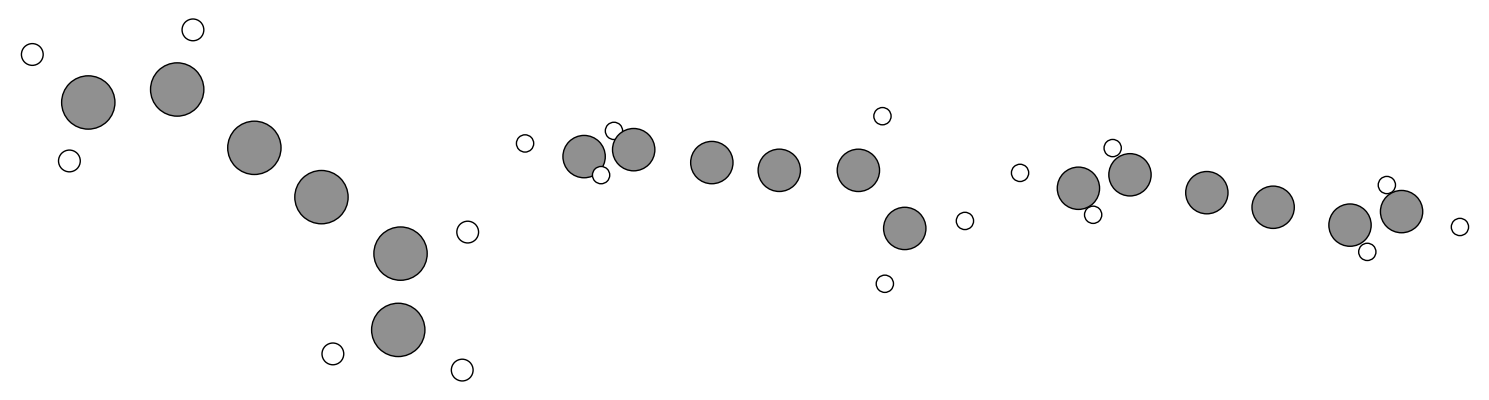

In [72]:
import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize.plot import plot_atoms

# Load your structures
atoms1 = read(StringIO(e_min_r_xyz), format="xyz")
atoms2 = read(StringIO(e_min_ts_xyz), format="xyz")
atoms3 = read(StringIO(e_min_p_xyz), format="xyz")

# Create a figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Define plotting parameters for consistency
rotation = '45x,45y,0z' # Apply the same rotation to each
radii = 0.5           # Adjust atom size
show_unit_cell = False

# Plot each structure
for ax, atoms in zip(axes, [atoms1, atoms2, atoms3]):
    plot_atoms(atoms, ax, rotation=rotation, radii=radii, show_unit_cell=show_unit_cell)
    ax.set_aspect('equal') # Ensures dimensions are balanced
    ax.axis('off')         # Removes axis ticks for a clean look

plt.tight_layout()
plt.show()

In [73]:
#from ase.visualize import view
#view(atoms1)

In [74]:
for xyz in [e_min_r_xyz, e_min_ts_xyz, e_min_p_xyz]:
    print(xyz)
    print("")

12

C	-0.6915106476019999	0.023594240967	-1.856948949987
C	-1.8846430713259998	-0.53080099379	-2.1497203872960005
C	0.313977425145	0.283946571245	0.573277547036
C	-0.15902179119200002	0.159180269998	-0.545422759761
C	0.8836653577419998	0.439067185522	1.866887557063
C	0.29795672603400003	0.051800401759999996	3.017386001056
H	-2.540840845885	-0.92531924092	-1.3654442587709998
H	-0.065705619511	0.406495709774	-2.6758084513429994
H	-0.689632301115	-0.4235199829149999	3.02570117446
H	1.875362880363	0.9121779393420001	1.9058605547999998
H	0.7991209461530001	0.204345698264	3.9796735347459995
H	-2.2298615888069997	-0.6009677992349999	-3.1871740419879995


12

C	-2.839828627074	-0.885098680244	-1.154036384367
C	-1.5008793165019998	-0.8539141481249999	-1.298818012004
C	0.21114913920399997	0.28657501819799996	0.36580556827399996
C	-0.591595970376	-0.258177205086	-0.37547776171
C	1.120592315046	1.062728280968	1.1429271721119998
C	1.840090266622	0.6491235746470001	2.2037970638379996
H	-1.0535617517

In [75]:
for xyz in [e_median_r_xyz, e_median_ts_xyz, e_median_p_xyz]:
    print(xyz)
    print("")

12

C	-0.406000038852	-0.37166195277499997	-0.8292935857409999
C	-1.827869434295	0.106964761478	-0.955988509729
C	0.949707908251	0.024197880855000003	-0.43291013722199995
C	-1.1818437336870002	-0.551706239771	0.239744730263
C	0.979518565444	0.061060878093	0.926366788211
C	-0.41113500117	-0.19523902595699996	1.4885324329119998
H	-2.5410452116059994	-0.480132103463	-1.553200963327
H	1.797227755536	0.210894738464	-1.0980714490869998
H	-0.433665413456	-0.9481097917349999	2.299205135476
H	1.8693209797069998	0.219389887124	1.545977144705
H	-0.838006505594	0.731281185436	1.921430393359
H	-2.047342400278	1.1930597822399998	-0.963524459791


12

C	-0.435739470952	-0.063459251649	-0.897615230117
C	-1.902548562251	0.155193557987	-1.007668558065
C	0.94871012482	0.46094526691099996	-0.6478801163609998
C	-1.1317742591529998	-0.469729933796	0.156387128981
C	1.025946167861	0.198895708988	0.755266291953
C	-0.310092720777	-0.256836978507	1.392704972699
H	-2.533797650714	-0.512921140114	-1.613603542714
H

In [76]:
draw_in_3dmol(e_min_r_xyz)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [77]:
draw_in_3dmol(e_min_ts_xyz)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [78]:
draw_in_3dmol(e_min_p_xyz)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [79]:
draw_in_3dmol(e_median_r_xyz)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [80]:
draw_in_3dmol(e_median_ts_xyz)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [81]:
draw_in_3dmol(e_median_p_xyz)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# 10/07/2026

 - evaluate three sets of log files
 - (make function to) print the key results for each model
 - find and visualize a successful triple.
 - inference old w-w-w model on test split --> com files --> GRRM launch

In [82]:
def read_out_batch_log_results(batch_log_results, batch_log_input_dirs):
    # What is the context of the results?
    print(f"The logs were in the directory:\n\t {batch_log_input_dirs['log_files_dir']}")
    print(f"The reference structures were in the file:\n\t {batch_log_input_dirs['ref_pkl_path']}")

    # Ratio of initial TS negative eigenvalues:
    initial_ts_has_negfreq = []
    for i, (rxn_name, val) in enumerate(batch_log_results.items()):
        initial_ts_has_negfreq.append(val["initial_TS_has_single_negative_eigenvalue"])
    ratio_initial_ts_has_negfreq = len([x for x in initial_ts_has_negfreq if x])/len(initial_ts_has_negfreq)
    print(f"Percentage of initial TS negative eigenvalues:\t\t\t{100*ratio_initial_ts_has_negfreq:2.4f}%")

    # Ratio of successful TS re-optimizations:
    ts_was_optimized = []
    for i, (rxn_name, val) in enumerate(batch_log_results.items()):
        ts_was_optimized.append(val["TS_was_successfully_reoptimized"])
    ratio_ts_was_optimized = len([x for x in ts_was_optimized if x])/len(ts_was_optimized)
    print(f"Percentage of successful TS re-optimizations:\t\t\t{100*ratio_ts_was_optimized:2.4f}%")

    # Ratio of both IRC EQs matched reference EQs:
    both_IRC_EQs_matched_ref_EQs = []
    for i, (rxn_name, val) in enumerate(batch_log_results.items()):
        if val["TS_was_successfully_reoptimized"]:
            both_IRC_EQs_matched_ref_EQs.append(val["both_IRC_EQs_matched_ref_EQs"])
    ratio_both_IRC_EQs_matched_ref_EQs = len([x for x in both_IRC_EQs_matched_ref_EQs if x])/len(both_IRC_EQs_matched_ref_EQs)
    print(f"Percentage of both IRC EQs matched reference EQs:\t\t {100*ratio_both_IRC_EQs_matched_ref_EQs:3.4f}%")

    # Ratio of at least one IRC EQ matched reference EQ:
    best_IRC_EQ_match_RMSDs = []
    for i, (rxn_name, val) in enumerate(batch_log_results.items()):
        if val["TS_was_successfully_reoptimized"]:
            if len([x for x in val["best_IRC_EQ_match_RMSDs"] if x is not None]) > 0:
                best_IRC_EQ_match_RMSDs.append(val["best_IRC_EQ_match_RMSDs"])
            else:
                pass
    ratio_oneplus_IRQ_EQ_match = len(best_IRC_EQ_match_RMSDs)/len([x for x in ts_was_optimized if x])
    print(f"Percentage of at least one IRC EQ matched reference EQ:\t\t{100*ratio_oneplus_IRQ_EQ_match:3.4f}%")

    # Re-optimization \Delta Energy:
    # TS_reopt_Delta_energy
    TS_reopt_Delta_energy = []
    for i, (rxn_name, val) in enumerate(batch_log_results.items()):
        if val["TS_was_successfully_reoptimized"]:
            TS_reopt_Delta_energy.append(val["TS_reopt_Delta_energy"])
    mean_delta_E = np.mean(TS_reopt_Delta_energy)
    stdev_delta_E = np.std(TS_reopt_Delta_energy)
    print(f"Mean (St.Dev.) of TS re-optimization \Delta E:\t\t\t{mean_delta_E:3.4f} (+- {stdev_delta_E:3.4f}) Hartree") # TODO verify eV not Hartree from GRRM?

    
    ts_cand_mode = "initial"
    best_cand_TS_match_RMSD = []
    for i, (rxn_name, val) in enumerate(batch_log_results.items()):
        if val["TS_was_successfully_reoptimized"]:
            best_cand_TS_match_RMSD.append(val[f"best_{ts_cand_mode}_TS_match_RMSD"])
    print(f"Percentage of {ts_cand_mode} TSes where an RMSD could be found:\t{100*len([x for x in best_cand_TS_match_RMSD if x is not None])/len(best_cand_TS_match_RMSD):3.4f}%")
    if len([x for x in best_cand_TS_match_RMSD if x is not None]) != 0:
        mean_cand_TS_vs_ref_TS_rmsd = np.mean([x for x in best_cand_TS_match_RMSD if x is not None])
        stdev_cand_TS_vs_ref_TS_rmsd = np.std([x for x in best_cand_TS_match_RMSD if x is not None])
        print(f"Mean (St.Dev.) of {ts_cand_mode} TS vs reference TS RMSD:\t\t{mean_cand_TS_vs_ref_TS_rmsd:3.4f} (+- {stdev_cand_TS_vs_ref_TS_rmsd:3.4f}) Å")

    best_IRC_EQ_match_RMSDs = []
    any_eq_match_count = 0
    for i, (rxn_name, val) in enumerate(batch_log_results.items()):
        if val["TS_was_successfully_reoptimized"]:
            if len(val["best_IRC_EQ_match_RMSDs"]) > 0:
                any_eq_match_count += 1
            for x in val["best_IRC_EQ_match_RMSDs"]:
                if x is not None:
                    best_IRC_EQ_match_RMSDs.append(x)
    mean_best_IRC_EQ_match_RMSDs = np.mean([x for x in best_IRC_EQ_match_RMSDs if x is not None])
    stdev_best_IRC_EQ_match_RMSDs = np.std([x for x in best_IRC_EQ_match_RMSDs if x is not None])
    print(f"Mean (St.Dev.) of RMSD between IRC EQ vs reference EQ:\t\t{mean_best_IRC_EQ_match_RMSDs:3.4f} (+- {stdev_best_IRC_EQ_match_RMSDs:3.4f}) Å")


read_out_batch_log_results(batch_log_results, batch_log_input_dirs)

The logs were in the directory:
	 /home/guest50/OAReactDiff/results/sample_random_TS-20260706-C6H6-filtered_combined_Ts1X-test/log-combined_C6H6_570-filtered_and_Ts1x-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet058abd800eca_ddpm-epoch=2947-val-totloss=470_70
The reference structures were in the file:
	 /scr/trond/SCAN/C6H6_5710-filtered-test.pkl
Percentage of initial TS negative eigenvalues:			50.0000%
Percentage of successful TS re-optimizations:			91.0000%
Percentage of both IRC EQs matched reference EQs:		 9.8901%
Percentage of at least one IRC EQ matched reference EQ:		46.1538%
Mean (St.Dev.) of TS re-optimization \Delta E:			0.0108 (+- 0.0277) Hartree
Percentage of initial TSes where an RMSD could be found:	52.7473%
Mean (St.Dev.) of initial TS vs reference TS RMSD:		0.3905 (+- 0.1177) Å
Mean (St.Dev.) of RMSD between IRC EQ vs reference EQ:		0.0010 (+- 0.0033) Å


In [83]:
len([x for x in both_IRC_EQs_matched_ref_EQs if x])

9

In [84]:
# UPDATE
# NB remove esccape backslashes.

# Get read-outs for three different sets of log files for TS generation against the C6H6-filtered validation split. 

log_files_dir = Path("/misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_test_split/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68/")
ref_pkl_path  = Path("/scr/trond/SCAN/C6H6_5710-filtered-test.pkl")

batch_log_results, batch_log_input_dirs = batch_process_grrm_saddlepoint_irc_log_files(log_files_dir, ref_pkl_path)

Reference instance 3730: Acceptable RMSD was not found.
Reference instance 4070: no saddle-point was found.
Reference instance 4070: Missing EQs after IRC calculation.
Reference instance 4276: no saddle-point was found.
Reference instance 4276: Missing EQs after IRC calculation.
Reference instance 5222: Acceptable RMSD was not found.
Reference instance 1218: Acceptable RMSD was not found.
Reference instance 3267: Acceptable RMSD was not found.


In [85]:
read_out_batch_log_results(batch_log_results, batch_log_input_dirs)

The logs were in the directory:
	 /misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_test_split/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68
The reference structures were in the file:
	 /scr/trond/SCAN/C6H6_5710-filtered-test.pkl
Percentage of initial TS negative eigenvalues:			51.0000%
Percentage of successful TS re-optimizations:			98.0000%
Percentage of both IRC EQs matched reference EQs:		 14.2857%
Percentage of at least one IRC EQ matched reference EQ:		58.1633%
Mean (St.Dev.) of TS re-optimization \Delta E:			0.0038 (+- 0.0216) Hartree
Percentage of initial TSes where an RMSD could be found:	48.9796%
Mean (St.Dev.) of initial TS vs reference TS RMSD:		0.3066 (+- 0.1650) Å
Mean (St.Dev.) of RMSD between IRC EQ vs reference EQ:		0.0008 (+- 0.0011) Å


In [88]:
# UPDATE
# NB remove esccape backslashes.

# Get read-outs for three different sets of log files for TS generation against the C6H6-filtered validation split. 

log_files_dir = Path("/misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_val_split/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68/")
ref_pkl_path  = Path("/scr/trond/SCAN/C6H6_5710-filtered-valid.pkl")

batch_log_results, batch_log_input_dirs = batch_process_grrm_saddlepoint_irc_log_files(log_files_dir, ref_pkl_path)

Reference instance 5600: Acceptable RMSD was not found.
Reference instance 3736: Acceptable RMSD was not found.
Reference instance 5869: Acceptable RMSD was not found.
Reference instance 3777: Acceptable RMSD was not found.
Reference instance 6103: Acceptable RMSD was not found.
Reference instance 6105: Acceptable RMSD was not found.
Reference instance 3854: Acceptable RMSD was not found.
Reference instance 6170: Acceptable RMSD was not found.
Reference instance 6181: Acceptable RMSD was not found.
Reference instance 4070: Acceptable RMSD was not found.
Reference instance 4079: Acceptable RMSD was not found.
Reference instance 6376: Acceptable RMSD was not found.
Reference instance 4276: Acceptable RMSD was not found.
Reference instance 6405: Acceptable RMSD was not found.
Reference instance 4465: Acceptable RMSD was not found.
Reference instance 6453: Acceptable RMSD was not found.
Reference instance 4495: Acceptable RMSD was not found.
Reference instance 6513: Acceptable RMSD was not

In [89]:
read_out_batch_log_results(batch_log_results, batch_log_input_dirs)

The logs were in the directory:
	 /misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_val_split/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68
The reference structures were in the file:
	 /scr/trond/SCAN/C6H6_5710-filtered-valid.pkl
Percentage of initial TS negative eigenvalues:			49.0000%
Percentage of successful TS re-optimizations:			99.0000%
Percentage of both IRC EQs matched reference EQs:		 0.0000%
Percentage of at least one IRC EQ matched reference EQ:		1.0101%
Mean (St.Dev.) of TS re-optimization \Delta E:			0.0099 (+- 0.0204) Hartree
Percentage of initial TSes where an RMSD could be found:	19.1919%
Mean (St.Dev.) of initial TS vs reference TS RMSD:		0.5346 (+- 0.0598) Å
Mean (St.Dev.) of RMSD between IRC EQ vs reference EQ:		0.0002 (+- 0.0001) Å


In [90]:
# UPDATE
# NB remove esccape backslashes.

# Get read-outs for three different sets of log files for TS generation against the C6H6-filtered validation split. 

log_files_dir = Path("/misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_val_split/log-combined_C6H6_570-filtered_and_Ts1x-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet058abd800eca_ddpm-epoch=2947-val-totloss=470_70/")
ref_pkl_path  = Path("/scr/trond/SCAN/C6H6_5710-filtered-valid.pkl")

batch_log_results, batch_log_input_dirs = batch_process_grrm_saddlepoint_irc_log_files(log_files_dir, ref_pkl_path)

Reference instance 5644: Acceptable RMSD was not found.
Reference instance 5600: Acceptable RMSD was not found.
Reference instance 3730: Acceptable RMSD was not found.
Reference instance 5745: Acceptable RMSD was not found.
Reference instance 3766: Acceptable RMSD was not found.
Reference instance 5869: Acceptable RMSD was not found.
Reference instance 3777: Acceptable RMSD was not found.
Reference instance 6103: no saddle-point was found.
Reference instance 6103: Missing EQs after IRC calculation.
Reference instance 3851: Acceptable RMSD was not found.
Reference instance 6105: Acceptable RMSD was not found.
Reference instance 3854: Acceptable RMSD was not found.
Reference instance 6170: Acceptable RMSD was not found.
Reference instance 6181: Acceptable RMSD was not found.
Reference instance 4070: Acceptable RMSD was not found.
Reference instance 4079: Acceptable RMSD was not found.
Reference instance 6376: Acceptable RMSD was not found.
Reference instance 6405: Acceptable RMSD was not

In [91]:
read_out_batch_log_results(batch_log_results, batch_log_input_dirs)

The logs were in the directory:
	 /misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_val_split/log-combined_C6H6_570-filtered_and_Ts1x-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet058abd800eca_ddpm-epoch=2947-val-totloss=470_70
The reference structures were in the file:
	 /scr/trond/SCAN/C6H6_5710-filtered-valid.pkl
Percentage of initial TS negative eigenvalues:			44.0000%
Percentage of successful TS re-optimizations:			95.0000%
Percentage of both IRC EQs matched reference EQs:		 0.0000%
Percentage of at least one IRC EQ matched reference EQ:		1.0526%
Mean (St.Dev.) of TS re-optimization \Delta E:			0.0166 (+- 0.0366) Hartree
Percentage of initial TSes where an RMSD could be found:	17.8947%
Mean (St.Dev.) of initial TS vs reference TS RMSD:		0.5152 (+- 0.0865) Å
Mean (St.Dev.) of RMSD between IRC EQ vs reference EQ:		0.0003 (+- 0.0000) Å


In [92]:
# UPDATE
# NB remove esccape backslashes.

# Get read-outs for three different sets of log files for TS generation against the C6H6-filtered validation split. 

log_files_dir = Path("/misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_val_split/log-C6H6_5710-0-wSL-wBL-w3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet53efbe37f1d9_ddpm-epoch=2760-val-totloss=471_14/")
ref_pkl_path  = Path("/scr/trond/SCAN/C6H6_5710-filtered-valid.pkl") # split-associated file doesn't matter if they all have the complete set of data. 

batch_log_results, batch_log_input_dirs = batch_process_grrm_saddlepoint_irc_log_files(log_files_dir, ref_pkl_path)

Reference instance 5644: Acceptable RMSD was not found.
Reference instance 3730: Acceptable RMSD was not found.
Reference instance 5745: Acceptable RMSD was not found.
Reference instance 3736: Acceptable RMSD was not found.
Reference instance 3777: Acceptable RMSD was not found.
Reference instance 6103: Acceptable RMSD was not found.
Reference instance 6105: Acceptable RMSD was not found.
Reference instance 3854: Acceptable RMSD was not found.
Reference instance 6181: Acceptable RMSD was not found.
Reference instance 4070: Acceptable RMSD was not found.
Reference instance 616: Acceptable RMSD was not found.
Reference instance 6376: Acceptable RMSD was not found.
Reference instance 4276: Acceptable RMSD was not found.
Reference instance 6405: Acceptable RMSD was not found.
Reference instance 4465: Acceptable RMSD was not found.
Reference instance 6453: Acceptable RMSD was not found.
Reference instance 4495: Acceptable RMSD was not found.
Reference instance 6513: Acceptable RMSD was not 

In [93]:
read_out_batch_log_results(batch_log_results, batch_log_input_dirs)

The logs were in the directory:
	 /misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_val_split/log-C6H6_5710-0-wSL-wBL-w3pBC-StepLR-cutoff_12-bz64-rep0-SCAN-leftnet53efbe37f1d9_ddpm-epoch=2760-val-totloss=471_14
The reference structures were in the file:
	 /scr/trond/SCAN/C6H6_5710-filtered-valid.pkl
Percentage of initial TS negative eigenvalues:			75.0000%
Percentage of successful TS re-optimizations:			100.0000%
Percentage of both IRC EQs matched reference EQs:		 0.0000%
Percentage of at least one IRC EQ matched reference EQ:		2.0000%
Mean (St.Dev.) of TS re-optimization \Delta E:			0.0038 (+- 0.0112) Hartree
Percentage of initial TSes where an RMSD could be found:	17.0000%
Mean (St.Dev.) of initial TS vs reference TS RMSD:		0.5365 (+- 0.0458) Å
Mean (St.Dev.) of RMSD between IRC EQ vs reference EQ:		0.0005 (+- 0.0001) Å


# Find for Ruben the best RMSD generated instance according to this evaluation from the pure C6H6 model against test split:

In [94]:
# UPDATE
# NB remove esccape backslashes.

# Get read-outs for three different sets of log files for TS generation against the C6H6-filtered validation split. 

log_files_dir = Path("/misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_test_split/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68/")
ref_pkl_path  = Path("/scr/trond/SCAN/C6H6_5710-filtered-test.pkl")

batch_log_results, batch_log_input_dirs = batch_process_grrm_saddlepoint_irc_log_files(log_files_dir, ref_pkl_path)

Reference instance 3730: Acceptable RMSD was not found.
Reference instance 4070: no saddle-point was found.
Reference instance 4070: Missing EQs after IRC calculation.
Reference instance 4276: no saddle-point was found.
Reference instance 4276: Missing EQs after IRC calculation.
Reference instance 5222: Acceptable RMSD was not found.
Reference instance 1218: Acceptable RMSD was not found.
Reference instance 3267: Acceptable RMSD was not found.


In [95]:
read_out_batch_log_results(batch_log_results, batch_log_input_dirs)

The logs were in the directory:
	 /misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_test_split/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68
The reference structures were in the file:
	 /scr/trond/SCAN/C6H6_5710-filtered-test.pkl
Percentage of initial TS negative eigenvalues:			51.0000%
Percentage of successful TS re-optimizations:			98.0000%
Percentage of both IRC EQs matched reference EQs:		 14.2857%
Percentage of at least one IRC EQ matched reference EQ:		58.1633%
Mean (St.Dev.) of TS re-optimization \Delta E:			0.0038 (+- 0.0216) Hartree
Percentage of initial TSes where an RMSD could be found:	48.9796%
Mean (St.Dev.) of initial TS vs reference TS RMSD:		0.3066 (+- 0.1650) Å
Mean (St.Dev.) of RMSD between IRC EQ vs reference EQ:		0.0008 (+- 0.0011) Å


In [96]:
min_rmsd = np.inf
min_rmsd_rxn_id = None
for i, (rxn_id, val) in enumerate(batch_log_results.items()):
    if val['TS_was_successfully_reoptimized']:
        if val["best_initial_TS_match_RMSD"] is not None:
            temp_rmsd = val["best_initial_TS_match_RMSD"]
            if temp_rmsd < min_rmsd:
                min_rmsd = temp_rmsd
                print(f"{rxn_id}: {min_rmsd}")
                min_rmsd_rxn_id = rxn_id

C6H6_5710-TS15932 CON(1163,1134): 0.18573455923062154
C6H6_5710-TS10080 CON(922,333): 0.06741379629980657
C6H6_5710-TS10845 CON(100,921): 0.008825791490453243


In [97]:
npz_path_train = "./oa_reactdiff/data/C6H6_5710-filtered/train.pkl"

train_pkl = pickle.load(open(npz_path_train, "rb"))
valid_pkl = pickle.load(open("/scr/trond/SCAN/C6H6_5710-filtered-valid.pkl", "rb"))
test_pkl = pickle.load(open("/scr/trond/SCAN/C6H6_5710-filtered-test.pkl", "rb"))

In [98]:
min_rmsd_ts_index = None
for i, rxn_id in enumerate(train_pkl["transition_state"]["rxn"]):
    if rxn_id == min_rmsd_rxn_id:
        min_rmsd_ts_index = i
        break
print(min_rmsd_rxn_id)
min_rmsd_ts_index

C6H6_5710-TS10845 CON(100,921)


3851

In [99]:
rmsd_min_r_xyz, rmsd_min_ts_xyz, rmsd_min_p_xyz = get_r_ts_p_xyzs_from_pkl(min_rmsd_ts_index, train_pkl, num_to_symbol=num_to_symbol)

In [100]:
print(rmsd_min_r_xyz)

12

C	0.503698449316	0.387411054897	-1.285628917265
C	-1.387370080501	0.087930718833	0.108141237126
C	-0.15405158580299996	-0.647038289371	-0.406124506924
C	-1.096990085474	-0.34688213857699995	1.559682536578
C	0.33259870455499996	-0.258813514178	0.9860714740880001
C	-0.072406153357	0.8560404838739999	0.027692539282999997
H	-2.31852705132	0.29393964575199993	-0.4305716777179999
H	1.5975245152639999	0.354377381713	-1.377085217068
H	-1.443831383701	-1.355709729126	1.8403315788149999
H	1.319168404328	-0.439375837246	1.426318530883
H	-1.349185666832	0.38715168590699994	2.343520913751
H	-0.02176059646	0.680968537512	-2.20408097154



In [101]:
print(rmsd_min_ts_xyz)

12

C	0.570817851057	0.46052016027599996	-1.208695176589
C	-1.338445190329	-0.020179919317999995	0.14227140314
C	-0.055566529869	-0.650747330295	-0.373069196546
C	-1.0754143335089998	-0.24282599877399996	1.6274387298180002
C	0.420614045817	0.1044034594	1.244982356578
C	-0.095786528475	0.843017379529	0.054515433391
H	-2.274567088935	0.06403693257	-0.43666894831
H	1.668774623336	0.48655035592999996	-1.231929697234
H	-1.2529011335479998	-1.25565658262	2.027173619237
H	0.7848475313609999	-0.995314426858	0.597883159267
H	-1.5177989577049997	0.50729143721	2.303225749782
H	0.074293180803	0.6989045329390001	-2.158859912536



In [102]:
print(rmsd_min_p_xyz)

12

C	-0.810727897975	-0.070951137392	1.129409203549
C	-0.985843730862	-0.13583472422	-0.333630887428
C	-0.617127479541	1.122913245908	-1.082151480602
C	0.4983764589429999	-0.093308982917	0.39922224811
C	0.7237894048489999	0.395146357563	-0.89968417007
C	0.306077668507	-1.0882816376709998	1.4588572585369999
H	-0.790644593667	2.042335060154	-0.49639514564900006
H	0.157944264104	-2.1541591765649994	1.219665810502
H	-0.9592292668059998	1.225030420583	-2.1211005233939995
H	0.8355973656829999	-0.9085799562049999	2.4034297114809995
H	-1.2528637130199998	-1.05756213719	-0.86447163066
H	-1.196481010167	0.723252667963	1.775117125598



In [106]:
log_parsing_results = parse_grrm_saddlepoint_irc_log("/misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_test_split/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68/C6H6_5710-TS10845_CON_100-921_.log")
pprint(log_parsing_results)

{'1st_irc_EQ_energy': -231.82500221031,
 '1st_irc_EQ_geometry': [['C', 1.318592989525, 0.908855499298, -0.193450997313],
                         ['C',
                          -1.478643623488,
                          -0.878265335857,
                          0.438854342154],
                         ['C',
                          -0.273925356422,
                          -0.874521340545,
                          -0.478436903409],
                         ['C',
                          -0.071418199935,
                          0.579782551233,
                          -0.771435661393],
                         ['C', 0.920564804214, 0.160097941585, 1.13298792146],
                         ['C', -0.443019832081, 0.181862946917, 0.643361948665],
                         ['H',
                          0.511002787379,
                          -1.640560076684,
                          -0.451296835795],
                         ['H',
                          -0.693701983928,
    

In [107]:
print(assemble_com(log_parsing_results["reopt_TS_geometry"]))

# SADDLE/B3LYP/Def2SVPP Int(Grid=FineGrid) EmpiricalDispersion=GD3

0 1
C	1.321457671057	0.895180320431	-0.210379848651
C	-1.438710605709	-0.886357680404	0.465373717891
C	-0.168933537972	-0.824515647735	-0.376450846084
C	-0.077007445022	0.64237045058	-0.762571975757
C	0.851286083093	-0.059885601603	0.960784998106
C	-0.561238024638	0.292659938291	0.630307973694
H	0.862197360763	-1.239462053462	0.353842551587
H	-0.641480671775	1.111901948991	-1.586851087441
H	1.513844303413	1.922765249724	0.139116090524
H	2.174689053261	0.540272472886	-0.812971559447
H	-2.388274563694	-0.763403402849	-0.0725915272
H	-1.447829622775	-1.631525994852	1.272391512776
Options
Saddle+IRC
DownDC = 99999
EigenCheck
GauProc=40
GauMem=200



In [109]:
assert min_rmsd_ts_index in valid_pkl["use_ind"]

## Try on valid

In [121]:

# Get read-outs for three different sets of log files for TS generation against the C6H6-filtered validation split. 

log_files_dir = Path("/misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_val_split/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68/")
ref_pkl_path  = Path("/scr/trond/SCAN/C6H6_5710-filtered-valid.pkl")

batch_log_results, batch_log_input_dirs = batch_process_grrm_saddlepoint_irc_log_files(log_files_dir, ref_pkl_path)

Reference instance 5600: Acceptable RMSD was not found.
Reference instance 3736: Acceptable RMSD was not found.
Reference instance 5869: Acceptable RMSD was not found.
Reference instance 3777: Acceptable RMSD was not found.
Reference instance 6103: Acceptable RMSD was not found.
Reference instance 6105: Acceptable RMSD was not found.
Reference instance 3854: Acceptable RMSD was not found.
Reference instance 6170: Acceptable RMSD was not found.
Reference instance 6181: Acceptable RMSD was not found.
Reference instance 4070: Acceptable RMSD was not found.
Reference instance 4079: Acceptable RMSD was not found.
Reference instance 6376: Acceptable RMSD was not found.
Reference instance 4276: Acceptable RMSD was not found.
Reference instance 6405: Acceptable RMSD was not found.
Reference instance 4465: Acceptable RMSD was not found.
Reference instance 6453: Acceptable RMSD was not found.
Reference instance 4495: Acceptable RMSD was not found.
Reference instance 6513: Acceptable RMSD was not

In [122]:
read_out_batch_log_results(batch_log_results, batch_log_input_dirs)

The logs were in the directory:
	 /misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_val_split/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68
The reference structures were in the file:
	 /scr/trond/SCAN/C6H6_5710-filtered-valid.pkl
Percentage of initial TS negative eigenvalues:			49.0000%
Percentage of successful TS re-optimizations:			99.0000%
Percentage of both IRC EQs matched reference EQs:		 0.0000%
Percentage of at least one IRC EQ matched reference EQ:		1.0101%
Mean (St.Dev.) of TS re-optimization \Delta E:			0.0099 (+- 0.0204) Hartree
Percentage of initial TSes where an RMSD could be found:	19.1919%
Mean (St.Dev.) of initial TS vs reference TS RMSD:		0.5346 (+- 0.0598) Å
Mean (St.Dev.) of RMSD between IRC EQ vs reference EQ:		0.0002 (+- 0.0001) Å


In [123]:
min_rmsd = np.inf
min_rmsd_rxn_id = None
for i, (rxn_id, val) in enumerate(batch_log_results.items()):
    if val['TS_was_successfully_reoptimized']:
        if val["best_initial_TS_match_RMSD"] is not None:
            temp_rmsd = val["best_initial_TS_match_RMSD"]
            if temp_rmsd < min_rmsd:
                min_rmsd = temp_rmsd
                print(f"{rxn_id}: {min_rmsd}")
                min_rmsd_rxn_id = rxn_id

C6H6_5710-TS10523 CON(197,136): 0.542955815697323
C6H6_5710-TS165 CON(24,23): 0.37967792310014725
C6H6_5710-TS14308 CON(1391,624): 0.37379443665432116


In [124]:
min_rmsd_ts_index = None
for i, rxn_id in enumerate(train_pkl["transition_state"]["rxn"]):
    if rxn_id == min_rmsd_rxn_id:
        min_rmsd_ts_index = i
        break
print(min_rmsd_rxn_id)
min_rmsd_ts_index

C6H6_5710-TS14308 CON(1391,624)


5104

In [125]:
rmsd_min_r_xyz, rmsd_min_ts_xyz, rmsd_min_p_xyz = get_r_ts_p_xyzs_from_pkl(min_rmsd_ts_index, train_pkl, num_to_symbol=num_to_symbol)
for xyz in [rmsd_min_r_xyz, rmsd_min_ts_xyz, rmsd_min_p_xyz]:
    print(xyz)
    print("")

12

C	-1.3919612256699998	-0.579242302327	-0.8325546418110001
C	-0.093343357549	-1.025680177317	-0.215346058923
C	0.104662252031	0.14500079491	0.707924626371
C	-1.1964490245129997	-0.608036943485	0.6598707681549999
C	1.046222388495	0.42773250533099993	1.760153617136
C	0.6499927318659999	1.511852908875	0.7432707691339999
H	-2.029375371128	-1.365532226897	-1.260653751558
H	-1.71948413632	-1.121273418008	1.468056127728
H	0.47792990830899995	-1.95313128523	-0.275575669875
H	1.441772188063	1.8277187290869998	0.044641690931
H	0.057746854046999994	2.351420715801	1.1421762208349997
H	-1.438845737631	0.389170699272	-1.353696178165


12

C	0.317546928575	0.429696037681	-0.9782952461459999
C	-0.5861215380599999	-0.687609977215	-0.528823135824
C	0.745616752806	-0.5701583809690001	0.074995236581
C	-1.227245504055	0.6607780525640001	1.631835444555
C	-0.295634505389	-0.328146310474	1.1034109344699998
C	-1.600708310051	-0.810193002432	1.1596956442099997
H	1.567635649916	-1.2879620391079998	0.080914053

In [126]:
log_parsing_results = parse_grrm_saddlepoint_irc_log("/misc/home/guest50/OAReactDiff/scratch/C6H6_saddle_validation/20260626-0707-log_files_batch_001/against_C6H6_filtered_val_split/log-C6H6_5710-filtered-LBS_32x8-StepLR-cutoff_21-rep0-SCAN-leftnet8ff8f5a1c6d0_ddpm-epoch=2932-val-totloss=457_68/C6H6_5710-TS14308_CON_1391_624_.log")
pprint(log_parsing_results)

{'1st_irc_EQ_energy': -231.876164176767,
 '1st_irc_EQ_geometry': [['C', 0.795510801992, 0.441379525975, -1.27607952203],
                         ['C', -0.041554112703, -0.61455632829, 0.75240141955],
                         ['C', -0.116208728256, 0.796269451665, 1.025953264403],
                         ['C',
                          -0.433502914665,
                          -0.07970045123,
                          -0.584694277459],
                         ['C', 0.26565766957, 1.378050859009, -0.222260612951],
                         ['C', 0.19546468955, -1.818555421596, 1.287517986095],
                         ['H',
                          1.719506180613,
                          -0.119203349204,
                          -1.080021881381],
                         ['H', -0.027035327164, -2.739523484784, 0.73829763901],
                         ['H', -0.082562259936, 2.377809196618, -0.51511408003],
                         ['H', 0.628161740833, -1.905056771788, 2.2900871058

In [127]:
print(assemble_com(log_parsing_results["reopt_TS_geometry"]))

# SADDLE/B3LYP/Def2SVPP Int(Grid=FineGrid) EmpiricalDispersion=GD3

0 1
C	0.69731515038	0.908809027368	-1.261695686528
C	0.325435949858	-0.770728491796	0.430065447324
C	0.471830366667	0.411872100284	1.173891862459
C	-0.104794443724	-0.327841193546	-0.908607027428
C	-0.225691027871	1.002283508233	-0.102734106479
C	-0.301477628138	-1.266291513743	1.566791898219
H	1.78482652245	0.917558482812	-1.092557038675
H	-1.346903790133	-1.614580273662	1.554388853726
H	-1.138135159088	1.605888846227	-0.06618944864
H	0.280866507533	-1.456265437158	2.468547049847
H	0.364076370983	1.411438726514	-2.177184343154
H	-0.807348818917	-0.822143781532	-1.584717460667
Options
Saddle+IRC
DownDC = 99999
EigenCheck
GauProc=40
GauMem=200



In [129]:
assert min_rmsd_ts_index in test_pkl["use_ind"]

AssertionError: 